# Анализ спроса на шеринговые самокаты

## Описание проекта
Компания, предоставляющая услуги аренды самокатов, недавно вышла на рынок. Собрав первые данные о поездках, она заинтересована в оптимизации бизнеса, в частности — в переходе на динамическое ценообразование.

## Цель проекта
Проанализировать эффективность текущей деятельности компании и выявить факторы, оказывающие влияние на спрос.

## План:
### Этап 0: Предобработка данных и знакомство с ними данных
### Этап 1: Проведение расчетов и исследований.
   #### 1.1 Итоговая стоимость
   #### 1.2 Таблица почасовый трафик
   #### 1.3 Корреляция между параметрами погоды
### Этап 2: Проверка гипотез
#### Предложенные гипотезы
### Этап 3: Регрессионное моделирование
   #### 3.1 Факторы
   #### 3.2 Нюансы
### Этап 4: Дашборд и презентация    
### Этап 5: Финальная сдача проекта

### Этап 0: Предобработка данных и знакомство с ними. Знакомство с данными

Два файла: weather.csv и rides.csv

# Weather.csv

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [1]:
import os
import networkx as nx
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
import math
from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind
from tqdm import tqdm
from scipy.stats import spearmanr

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
warnings.filterwarnings('ignore')

In [2]:
w = pd.read_csv('weather.csv')
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

# Rides.csv

In [3]:
df = pd.read_csv('rides.csv')
df.info()
data_num = len(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


0.   Id - идентификатор поездки              
 1.   Start Date - Start Datetime     
 2.   End Date - End Datetime        
 3.   Start Location - Start Location  
 4.   Start District - Start District   
 5.   End Location - End Location    
 6.   End District - End District    
 7.   Distance - Distance        
 8.   Promo - применен ли промо-код на бесплатный старт

<!-- # *Предобработаем данные по следующему плану:

#### Этап 1: Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки) -->

### Этап 1:Проведение расчетов и исследований.

Общая информация про файл rides.csv

In [4]:
df = pd.read_csv('rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

<!-- Удалено дубликатов: 4883<br>
Было: 102255, Стало: 97372 -->

In [5]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


Есть несколько вещей, которые необходимо проверить и выполнить, прежде чем можно будет продолжить анализ.

- Переименование столбцов, чтобы исключить пустое пространство между именами столбцов
- Проверка того, что столбцы имеют соответствующий тип данных
- Проверьте и удалите значения N / A или дублированные значения, если таковые имеются
- Проверьте, нет ли аномалий в категориальных и числовых столбцах (опечаток, значений, которые не имеют смысла, и т.д.)

#### Переименование столбцов

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
cols = df.copy()

#### Определение типов

In [7]:
for col in cols.columns:
    print(col + ' has the datatype: \t',  cols[col].dtype)

id has the datatype: 	 int64
start_date has the datatype: 	 object
end_date has the datatype: 	 object
start_location has the datatype: 	 object
start_district has the datatype: 	 object
end_location has the datatype: 	 object
end_district has the datatype: 	 object
distance has the datatype: 	 object
promo has the datatype: 	 int64


- Судя по результатам, дата поездки не распознается как объект datetime. Ее необходимо преобразовать в столбец объекта datetime.
- По опыту, данные о месяцах, начале поездки и другие ячейки также могут быть полезны. Они будут извлечены в отдельный столбец для облегчения доступа.

In [8]:
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df.head(5)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0


In [9]:
seasons = {
    12: 'зима', 1: 'зима', 2: 'зима',
    3: 'весна', 4: 'весна', 5: 'весна',
    6: 'лето', 7: 'лето', 8: 'лето',
    9: 'осень', 10: 'осень', 11: 'осень'
}

df['start_month'] = df['start_date'].dt.month
df['start_season'] = df['start_month'].map(seasons)

df['start_hour'] = df['start_date'].dt.hour

def time_of_day(x):
    if 5 <= x <= 12:
        return 'утро'
    elif 12 < x <= 18:
        return 'день'
    elif 18 < x <= 22:
        return 'вечер'
    return 'ночь'

df['time_of_day'] = df['start_date'].apply(lambda x: time_of_day(x.hour))
df['weekday'] = df['start_date'].dt.weekday

df['day_type'] = df['weekday'].apply(lambda x: 'будний день' if x < 5 else 'выходной')
df['days'] = df['start_date'].dt.day

df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')
df['speed'] = (df['distance'] / 1000) / (df['duration'] / 60)

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,start_season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0,4,весна,9,утро,5,выходной,22,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


#### Нужно посмотреть пропуски по дате, чтобы заранее не тянуть за собой лишние ячейки

In [10]:
missing_dates = df[['start_date', 'end_date']].isnull().sum()

print("Количество пропущенных значений в датах:")
print(missing_dates)

Количество пропущенных значений в датах:
start_date      0
end_date      579
dtype: int64


In [11]:
df['distance'].describe()

count    1.010220e+05
mean     2.729110e+04
std      3.097186e+05
min      1.000000e+00
25%      3.044000e+03
50%      3.702000e+03
75%      4.429000e+03
max      7.569789e+06
Name: distance, dtype: float64

Получается, что в строках, где нет конечной даты, остальные данные -  не нулевые

##### Всего пропущенных значений в конечной дате (end_date): 579
##### Чтобы не терять данные, можно восстановить пропущенное время на основе регрессии

In [12]:
valid = df[(df['end_date'].notnull()) & (df['distance'] > 100) & (df['duration'] > 1) & (df['speed'] < 20)]
X = valid[['distance']]
y = valid['duration']

model = LinearRegression()
model.fit(X, y)

missing = df[df['end_date'].isnull()].copy()
missing['predicted_duration'] = model.predict(missing[['distance']])
missing['predicted_duration'] = missing['predicted_duration'].clip(lower=3)

missing['predicted_duration'] = missing['predicted_duration'].round().astype(int)
missing['end_date'] = missing['start_date'] + pd.to_timedelta(missing['predicted_duration'], unit='m')

df.update(missing[['end_date']])
print("Оставшиеся пропуски в end_date:", df['end_date'].isnull().sum())

Оставшиеся пропуски в end_date: 0


#### Теперь проверим, остались ли пропуски в остальных столбцах

In [13]:
missing_values = df.isna().sum()
print(missing_values)

null_rows = df[df.isna().any(axis=1)]
null_rows.head(10)

id                   0
start_date           0
end_date             0
start_location       0
start_district       0
end_location         0
end_district         0
distance          1233
promo                0
start_month          0
start_season         0
start_hour           0
time_of_day          0
weekday              0
day_type             0
days                 0
duration           579
speed             1812
dtype: int64


,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,start_season,start_hour,time_of_day,weekday,day_type,days,duration,speed
188,100517,2023-04-22 13:53:36,2023-04-22 14:16:43,Цветочная,Северо-Западный,ул. мичурина,Ленинский,NaN,0,4,весна,13,день,5,выходной,22,23.116667,NaN
256,100582,2023-04-22 14:56:38,2023-04-22 15:36:18,вишневая,Юго-Восточный,московская,Северо-Западный,NaN,0,4,весна,14,день,5,выходной,22,39.666667,NaN
291,100615,2023-04-22 15:25:04,2023-04-22 15:42:43,Ломоносова,Октябрьский,Куйбышева,центральный,NaN,0,4,весна,15,день,5,выходной,22,17.650000,NaN
312,100636,2023-04-22 15:44:25,2023-04-22 16:10:25,мичурина,Ленинский,кирова,ленинский,3739.0,0,4,весна,15,день,5,выходной,22,NaN,NaN
407,100725,2023-04-22 16:52:47,2023-04-22 17:11:47,Партизанская,ленинский,ул. вишневая,юго-восточный,2721.0,0,4,весна,16,день,5,выходной,22,NaN,NaN
486,100799,2023-04-22 17:51:45,2023-04-22 18:24:45,гагарина,Центральный,ул.партизанская,Ленинский,4789.0,0,4,весна,17,день,5,выходной,22,NaN,NaN
495,100807,2023-04-22 17:58:05,2023-04-22 18:01:05,Ломоносова,октябрьский,ул. цветочная,Северо-Западный,4.0,0,4,весна,17,день,5,выходной,22,NaN,NaN
501,100813,2023-04-22 18:02:47,2023-04-22 18:58:57,Почтовая,юго-восточный,Солнечная,Центральный,NaN,0,4,весна,18,день,5,выходной,22,56.166667,NaN
515,100827,2023-04-22 18:10:22,2023-04-22 18:49:17,ул.школьная,Северо-Западный,ул.юбилейная,Юго-Восточный,NaN,0,4,весна,18,день,5,выходной,22,38.916667,NaN
637,100944,2023-04-22 19:18:20,2023-04-22 19:54:54,Пролетарская,Центральный,Заречная,Юго-Восточный,NaN,0,4,весна,19,вечер,5,выходной,22,36.566667,NaN


#### Осталось пересчитать duration и speed, так как она пострадала за счет тех нулевых значений

In [14]:
df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60
df['speed'] = (df['distance'] / 1000) / (df['duration'] / 60)
missing_values = df.isna().sum()
print(missing_values)

id                   0
start_date           0
end_date             0
start_location       0
start_district       0
end_location         0
end_district         0
distance          1233
promo                0
start_month          0
start_season         0
start_hour           0
time_of_day          0
weekday              0
day_type             0
days                 0
duration             0
speed             1233
dtype: int64


## Неявные дубликаты

#### Для начала смотрим формат написания улиц и сводим его к одному стилю

In [15]:
print(df['start_location'].unique(), df['start_district'].unique())
print(df.duplicated().sum())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

#### Замена названий улиц

In [16]:
def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['start_location'] = df['start_location'].apply(clean_street)
df['start_district'] = df['start_district'].apply(lambda x: x.lower().replace(' ', '-'))
df['end_location'] = df['end_location'].apply(clean_street)
df['end_district'] = df['end_district'].apply(lambda x: x.lower().replace(' ', '-'))

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,start_season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,весна,9,утро,5,выходной,22,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


Распределение улиц по районам

In [17]:
grouped_streets_by_district = df.groupby('start_district')['start_location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['start_location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,start_location,1
start_district,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


#### Далее посмотрим графики распределения категориальных признаков для выявления аномалий

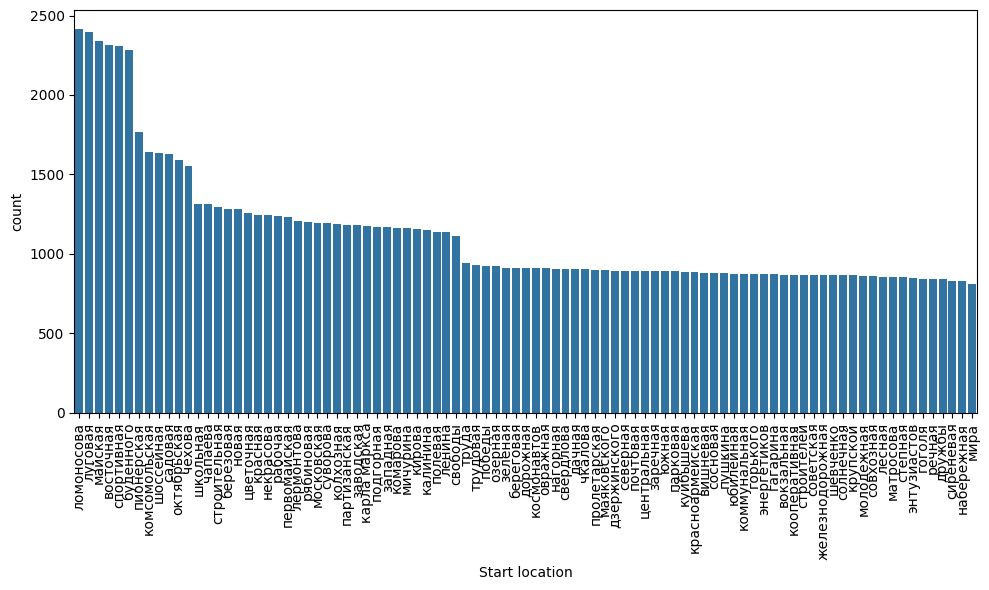

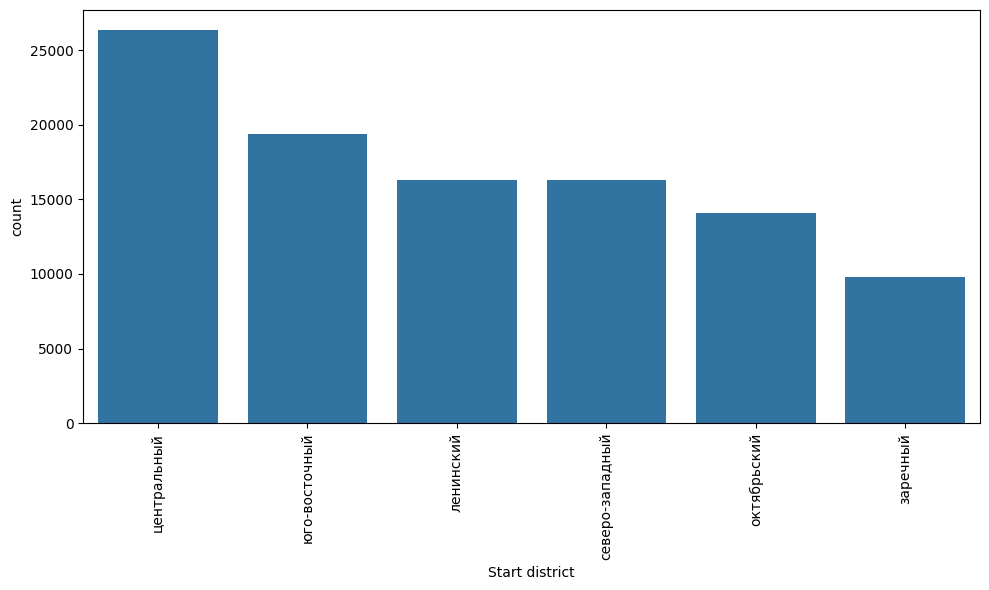

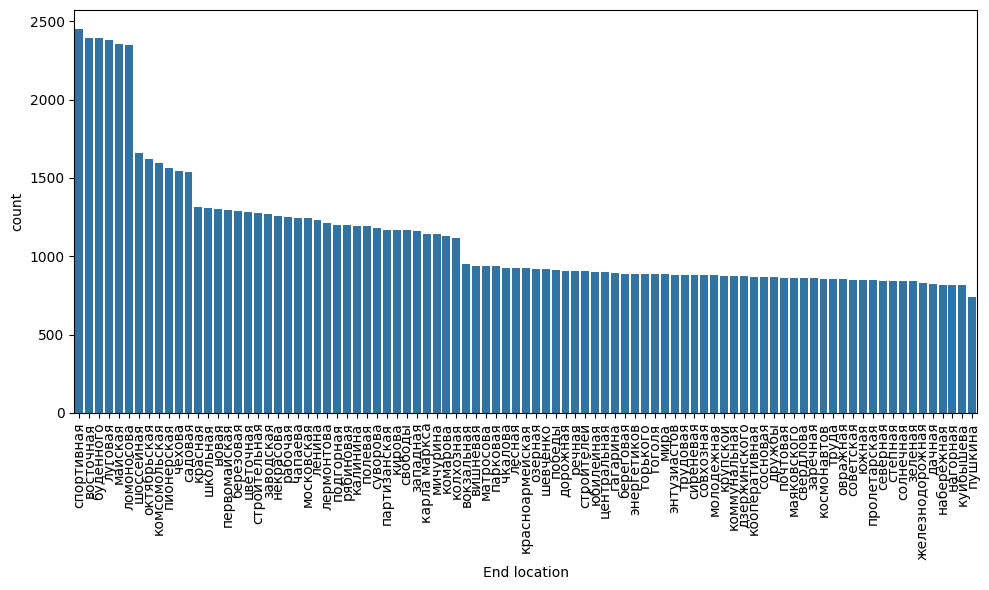

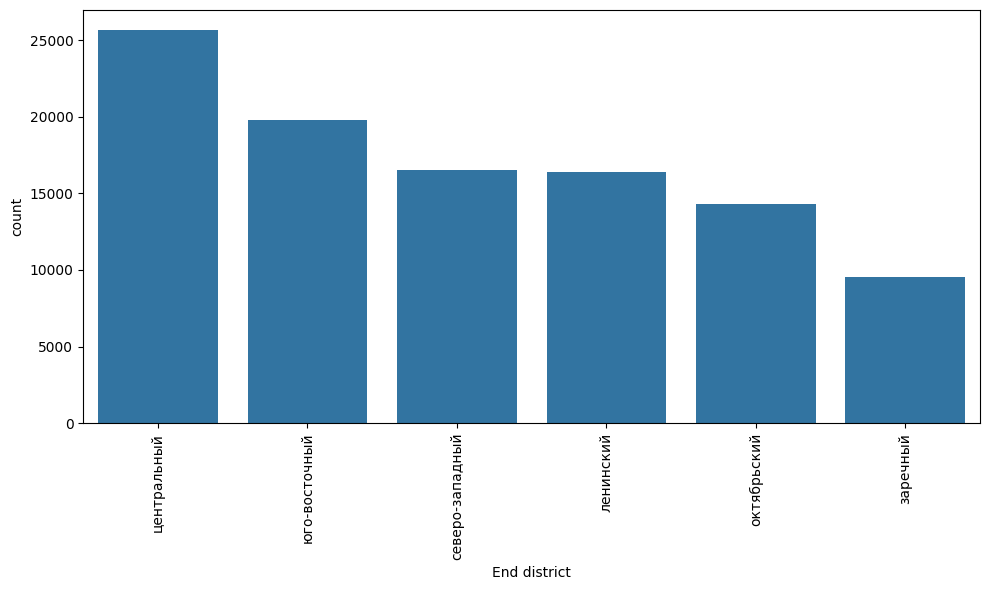

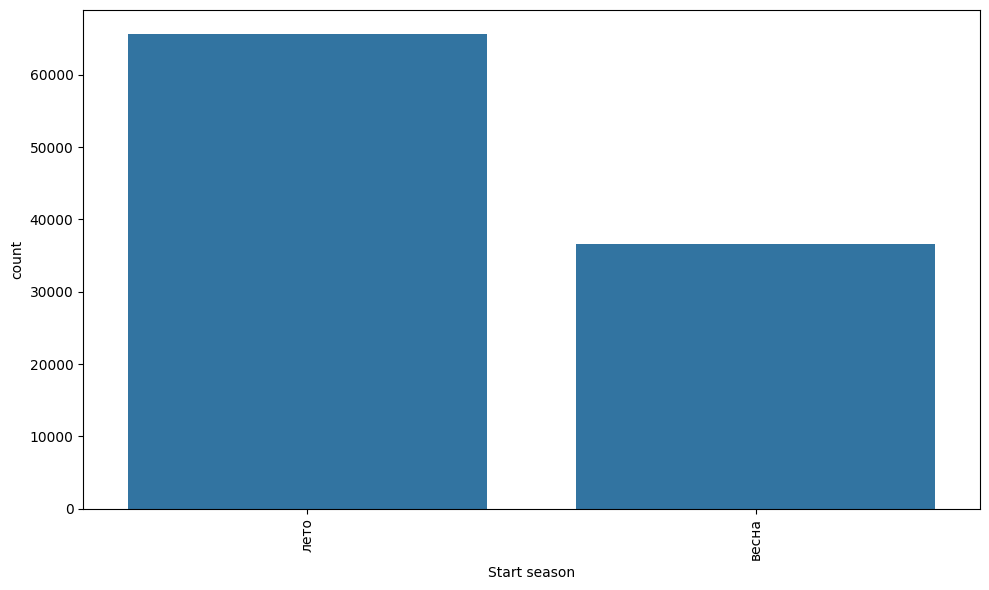

In [18]:
categorical_columns = ['start_location','start_district', 'end_location','end_district','start_season']

def plot_all_hist(df, columns):
    for col in columns:
        plt.figure(figsize=(10, 6))
        order = df[col].value_counts().index
        sns.countplot(x=col, data=df, order=order)
        plt.xlabel(col.replace('_', ' ').capitalize())
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

plot_all_hist(df, categorical_columns)

##### Аномальных значений не найдено, приведение улиц к одному формату позволило избежать неправильного распределения

#### Теперь посмотрим распределение количественных признаков для выявления аномалий

In [19]:
numerical_cols = ['distance','duration','speed']
df[numerical_cols].describe()

,distance,duration,speed
count,1.010220e+05,102255.000000,101022.000000
mean,2.729110e+04,26.905216,65.260925
std,3.097186e+05,127.523622,734.800708
min,1.000000e+00,2.566667,0.002395
25%,3.044000e+03,19.483333,7.671724
50%,3.702000e+03,24.633333,9.100024
75%,4.429000e+03,31.216667,10.531554
max,7.569789e+06,35336.000000,15580.652700


##### Есть значительные выбросы, которые можно заметить по колонке speed, так как максимальная скорость 15580, чего физически не может быть, именно поэтому среднее не соотносится со значениями квартилей

In [20]:
Q1 = df['speed'].quantile(0.25)
Q3 = df['speed'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df_check_anomalies = df[(df['speed'] >= lower_bound) & (df['speed'] <= upper_bound)]
df_check_anomalies.head(10)
df_check_anomalies['speed'].describe()

count    100401.000000
mean          8.904946
std           2.554115
min           0.002395
25%           7.659433
50%           9.083429
75%          10.500201
max          17.604723
Name: speed, dtype: float64

Чтобы сравнить распределение до после построим графики дистанции и сокрости

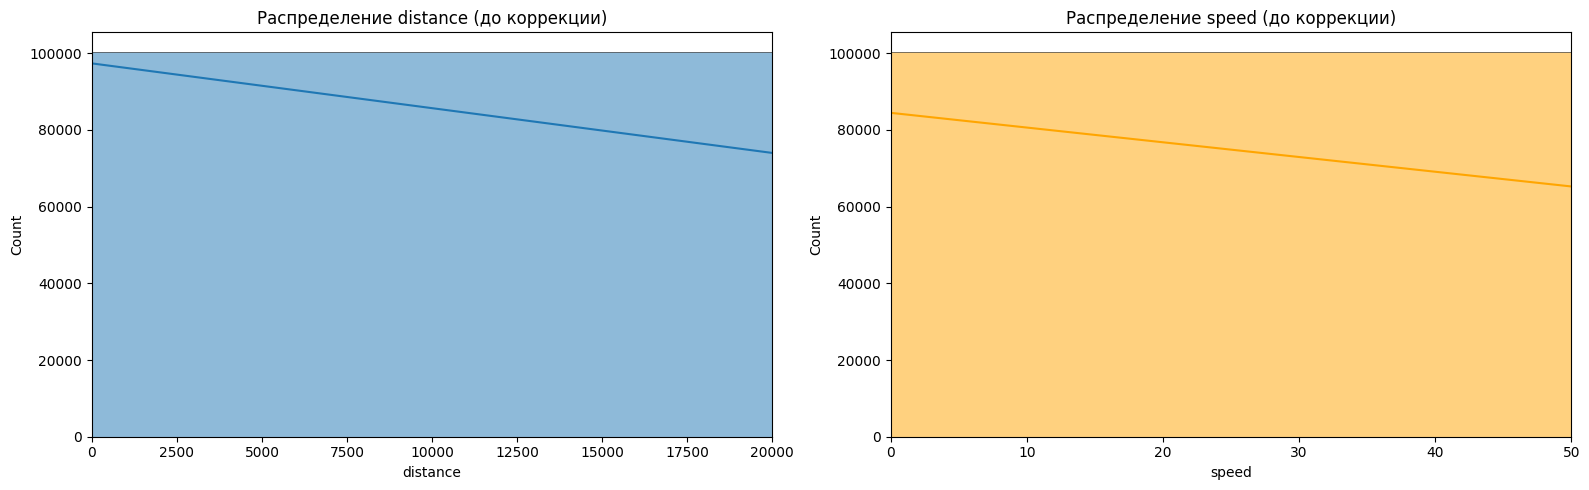

In [21]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['distance'], bins=100, kde=True)
plt.title("Распределение distance (до коррекции)")
plt.xlim(0, 20000)

plt.subplot(1, 2, 2)
sns.histplot(df['speed'], bins=100, kde=True, color='orange')
plt.title("Распределение speed (до коррекции)")
plt.xlim(0, 50)

plt.tight_layout()
plt.show()


Для исправления аномальных значений воспользуемся градиентым бустингом, учитывая факторы, которые могут повлиять на изменение дистанции. Применяется такой способ, чтобы не просто брать среднюю скорость, а стараться учесть другие признаки для более точного попадания

In [22]:
df_model = df[(df['speed'] > 3) & (df['speed'] < 40) & (df['duration'] > 1)].copy()

features = ['duration', 'start_hour', 'weekday', 'day_type', 'start_season', 'time_of_day']
target = 'distance'

cat_features = ['weekday', 'day_type', 'start_season', 'time_of_day']
num_features = ['duration', 'start_hour']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('num', 'passthrough', num_features)
])

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('reg', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
])

X = df_model[features]
y = df_model[target]

model.fit(X, y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weekday', 'day_type',
                                                   'start_season',
                                                   'time_of_day']),
                                                 ('num', 'passthrough',
                                                  ['duration',
                                                   'start_hour'])])),
                ('reg',
                 GradientBoostingRegressor(max_depth=5, n_estimators=200,
                                           random_state=42))])

Чтобы заменить значения, нужно понять, что является нормальным значением и применять до верхней границы 95%

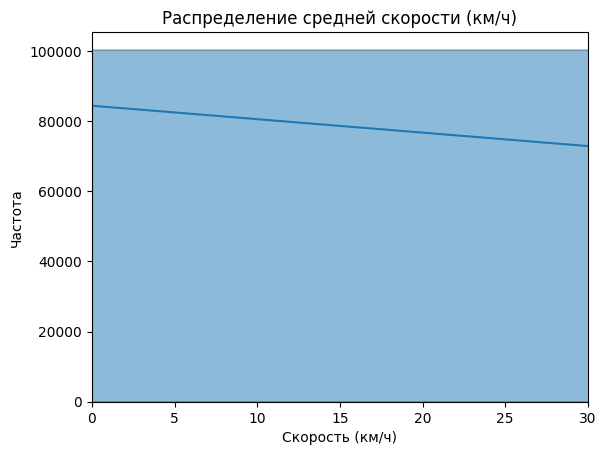

count    101022.000000
mean         65.260925
std         734.800708
min           0.002395
1%            0.008188
5%            5.052086
25%           7.671724
50%           9.100024
75%          10.531554
95%          12.657362
99%          14.666997
max       15580.652700
Name: speed, dtype: float64
5.052085632186417 12.657361805115983


In [23]:
sns.histplot(df['speed'], bins=100, kde=True)
plt.title('Распределение средней скорости (км/ч)')
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Частота')
plt.xlim(0, 30)  # чтобы отсечь экстремумы
plt.show()

print(df['speed'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
low_speed = df['speed'].quantile(0.05)
high_speed = df['speed'].quantile(0.95)
print(low_speed, high_speed)

In [24]:
mask_outliers = (
    ((df['duration'] > 5) & (df['duration'] < 90) & ((df['speed'] < low_speed) | (df['speed'] > high_speed)))
    | (df['distance'].isna())
)

df_outliers = df[mask_outliers].copy()
df.loc[mask_outliers, 'distance'] = model.predict(df_outliers[features])

df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60
df['speed'] = (df['distance'] / 1000) / (df['duration'] / 60)


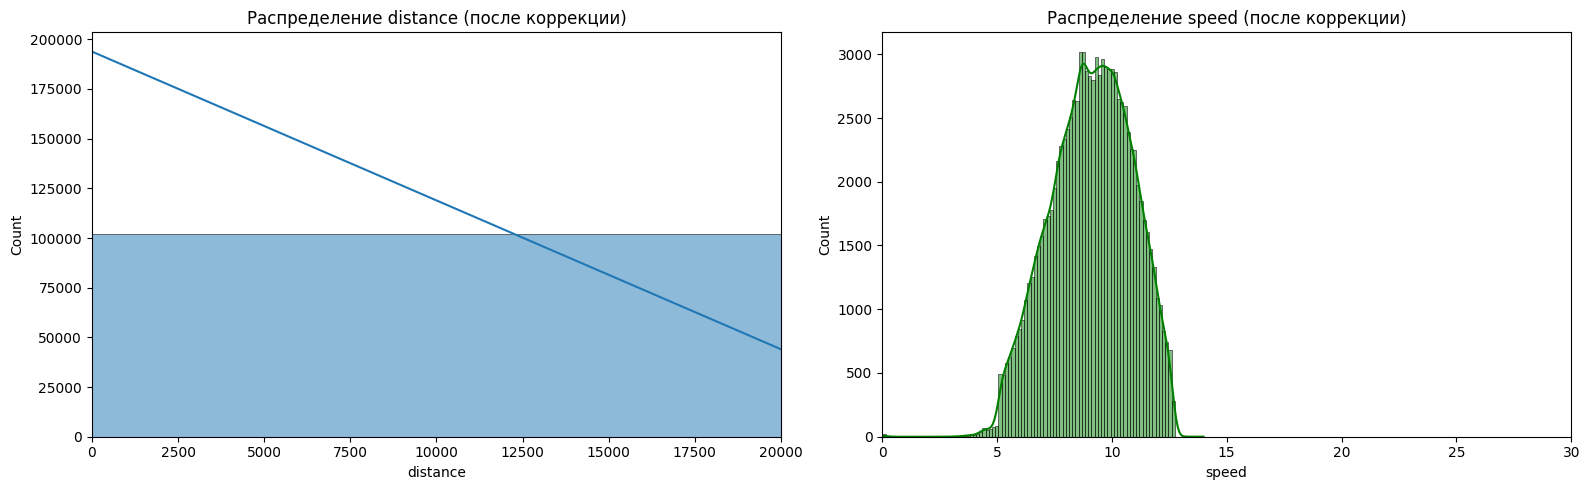

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,start_season,start_hour,time_of_day,weekday,day_type,days,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,весна,9,утро,5,выходной,22,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,весна,9,утро,5,выходной,22,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,весна,9,утро,5,выходной,22,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,весна,9,утро,5,выходной,22,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,весна,9,утро,5,выходной,22,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,весна,9,утро,5,выходной,22,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,весна,9,утро,5,выходной,22,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,весна,9,утро,5,выходной,22,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3040.987848,0,4,весна,9,утро,5,выходной,22,17.366667,10.506292
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,весна,9,утро,5,выходной,22,34.133333,9.251367


In [25]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['distance'], bins=100, kde=True)
plt.title("Распределение distance (после коррекции)")
plt.xlim(0, 20000)

plt.subplot(1, 2, 2)
sns.histplot(df['speed'], bins=100, kde=True, color='green')
plt.title("Распределение speed (после коррекции)")
plt.xlim(0, 30)

plt.tight_layout()
plt.show()
df.head(10)

In [26]:
df['speed'].describe()

count    102255.000000
mean          9.096719
std           1.752781
min           0.040000
25%           7.854781
50%           9.175245
75%          10.424177
max          13.991489
Name: speed, dtype: float64

In [27]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 4883


In [28]:
print(f"Было {data_num}")
print(f"Стало {len(df)}")

Было 102255
Стало 97372


#### ИТОГ:
- Привели столбцы к PEP-8
- Заменили названия улиц и районов для правильного распределения
- С помощью регрессии заменили 579 пропусков в end_date
- С помощью градиентного бустинга убрали аномалии в дистанции

### Добавление дополнительных столбцов

#### Добавление стоимости в зависимости от промежутка дня, полная стоимость поездки (со стартом и без)

In [29]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


def calculate_trip_cost(row):
    weekday = row['weekday']
    start_hour = row['start_hour']
    duration = row['duration']
    promo = row['promo']

    rate = get_rate(weekday, start_hour)

    # Если акция, бесплатный старт, но учитываем длительность и стоимость минуты
    if promo == 1 and (weekday == 0 and 6 <= start_hour < 10):  # Понедельник, с 6:00 до 10:00
        return duration * rate  # бесплатный старт, считаем только длительность * стоимость минуты
    else:
        # Если без промо или не понедельник с акцией
        return start_cost + (duration * rate)


start_cost = 30

df['rate_per_minute'] = df.apply(lambda row: get_rate(row['weekday'], row['start_hour']), axis=1)
df['cost'] = df.apply(calculate_trip_cost, axis=1)
df['cost_no_start'] = df['duration'] * df['rate_per_minute']

df.head(10)

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,start_hour,time_of_day,weekday,day_type,days,duration,speed,rate_per_minute,cost,cost_no_start
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.000000,0,4,...,9,утро,5,выходной,22,23.700000,10.301266,4,124.800000,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.000000,0,4,...,9,утро,5,выходной,22,28.416667,9.533138,4,143.666667,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.000000,0,4,...,9,утро,5,выходной,22,38.316667,7.077860,4,183.266667,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.000000,0,4,...,9,утро,5,выходной,22,31.816667,7.318806,4,157.266667,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.000000,0,4,...,9,утро,5,выходной,22,30.666667,7.882826,4,152.666667,122.666667
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.000000,0,4,...,9,утро,5,выходной,22,39.783333,7.358358,4,189.133333,159.133333
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.000000,0,4,...,9,утро,5,выходной,22,10.816667,10.239753,4,73.266667,43.266667
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.000000,0,4,...,9,утро,5,выходной,22,20.833333,9.023040,4,113.333333,83.333333
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3040.987848,0,4,...,9,утро,5,выходной,22,17.366667,10.506292,4,99.466667,69.466667
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.000000,0,4,...,9,утро,5,выходной,22,34.133333,9.251367,4,166.533333,136.533333


#### Добавление нужных столбиков дат

In [30]:
df['day_of_week'] = df['start_date'].dt.day_name()
df['end_month'] = df['end_date'].dt.month
df['end_season'] = df['end_month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'


df['date'] = df['start_date'].apply(lambda x: str(x.year) + ' ' + str(x.month) + ' ' + str(x.day) + ' ' + str(x.hour))
df['start_hour'] = df['start_date'].dt.hour
df['end_hour'] = df['end_date'].dt.hour

Анализируем столбец: distance
Оставлено 96397 значений из 97372 (ограничено по 99-му процентилю: 6574.00)
count    96397.000000
mean      3774.855535
std        967.483607
min          2.000000
25%       3083.000000
50%       3709.000000
75%       4421.000000
max       6573.000000
Name: distance, dtype: float64



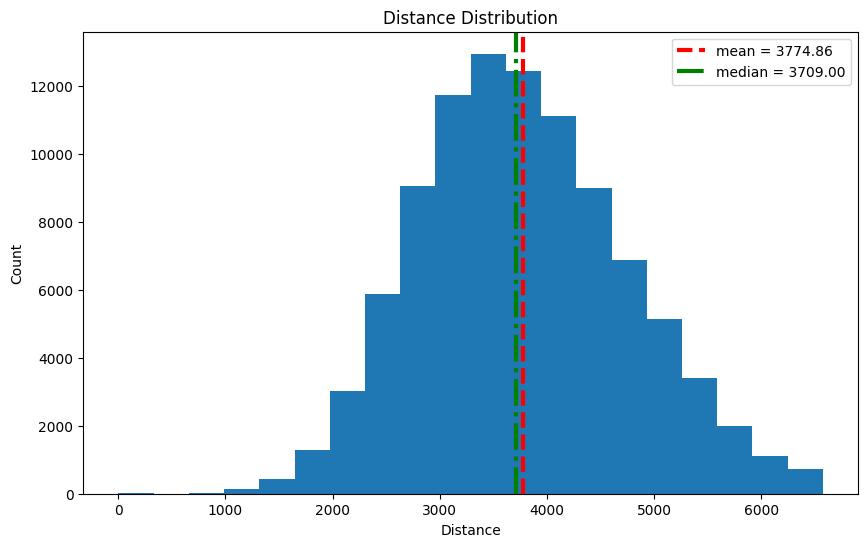


Анализируем столбец: duration
Оставлено 96398 значений из 97372 (ограничено по 99-му процентилю: 59.39)
count    96398.000000
mean        25.957899
std          9.076415
min          2.566667
25%         19.433333
50%         24.516667
75%         30.950000
max         59.383333
Name: duration, dtype: float64



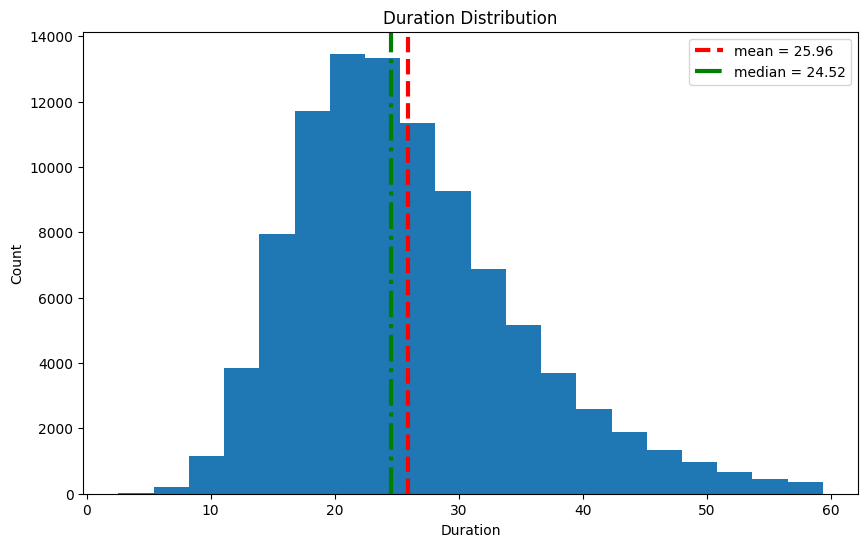


Анализируем столбец: speed
Всего значений: 97372
count    97372.000000
mean         9.096790
std          1.752682
min          0.040000
25%          7.855293
50%          9.174957
75%         10.425286
max         13.991489
Name: speed, dtype: float64



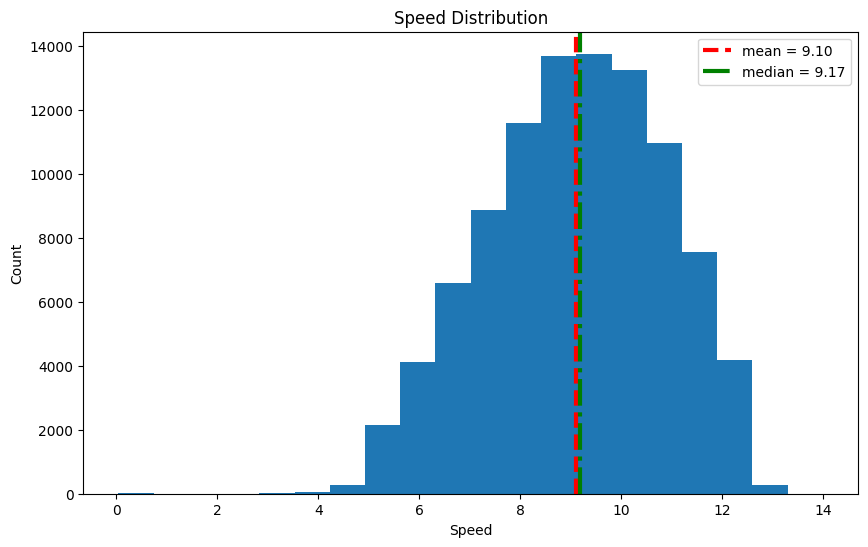


Анализируем столбец: cost
Оставлено 96396 значений из 97372 (ограничено по 99-му процентилю: 394.82)
count    96396.000000
mean       175.830965
std         60.012106
min         21.133333
25%        132.300000
50%        166.500000
75%        210.000000
max        394.800000
Name: cost, dtype: float64



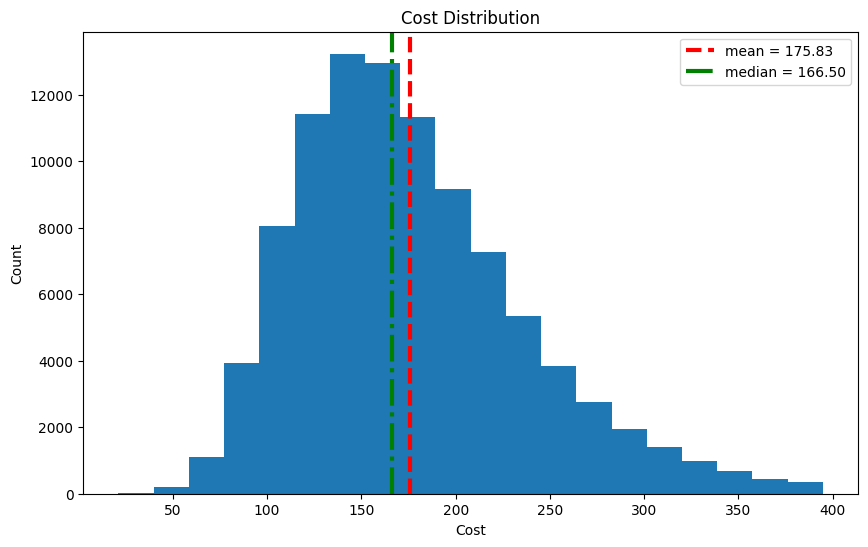

In [31]:
numerical_cols = ['distance', 'duration', 'speed', 'cost']

def plot_num_histogram(columns):
    for col in columns:
        print(f'Анализируем столбец: {col}')

        if col == 'duration' or col == 'distance' or col == 'cost':
            upper_limit = df[col].quantile(0.99)
            filtered = df[df[col] < upper_limit]
            print(f'Оставлено {len(filtered)} значений из {len(df)} (ограничено по 99-му процентилю: {upper_limit:.2f})')
        else:
            filtered = df
            print(f'Всего значений: {len(filtered)}')

        print(filtered[col].describe())
        print("")

        plt.figure(figsize=(10,6))
        plt.hist(filtered[col], bins=20)
        plt.title(f'{col.capitalize()} Distribution')
        plt.xlabel(col.capitalize())
        plt.ylabel('Count')
        plt.axvline(filtered[col].mean(), color='red', linestyle='dashed', linewidth=3, label='mean = {:.2f}'.format(filtered[col].mean()))
        plt.axvline(filtered[col].median(), color='green', linestyle='dashdot', linewidth=3, label='median = {:.2f}'.format(filtered[col].median()))
        plt.legend()
        plt.show()
        print('')

plot_num_histogram(numerical_cols)
for col in numerical_cols:
    upper_limit = df[col].quantile(0.99)
    df = df[df[col] < upper_limit]

##### Почему могли возникнуть аномалии и такие выбросы?
##### - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
##### - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS

Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.

# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

start_season
весна    25.540141
лето     25.555673
Name: duration, dtype: float64
day_of_week
Sunday       17196
Saturday     17031
Friday       13683
Monday       12340
Wednesday    11289
Thursday     11151
Tuesday      10842
Name: count, dtype: int64
start_hour
0     1099
1      552
2      422
3      184
4      211
5      807
6     2375
7     3401
8     3861
9     3713
10    3580
11    3151
12    3525
13    4033
14    5100
15    5885
16    6738
17    7429
18    7834
19    8314
20    7780
21    6026
22    4673
23    2839
Name: count, dtype: int64


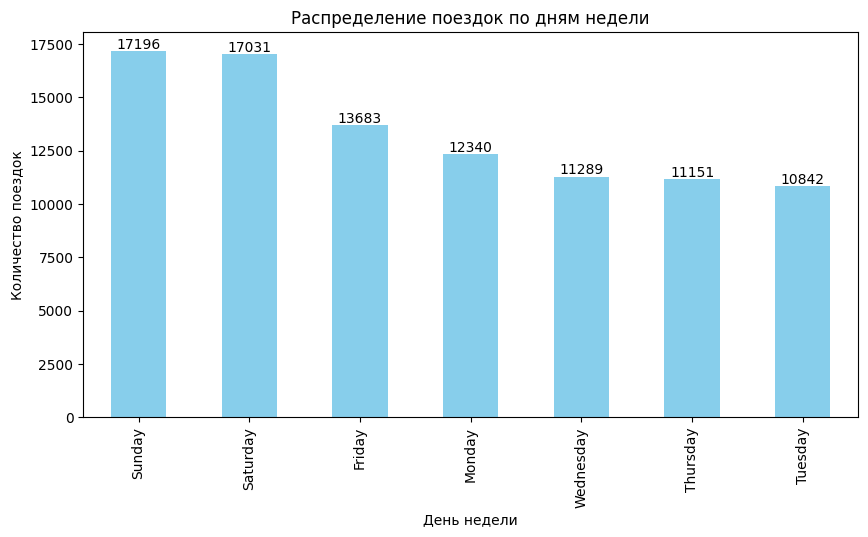

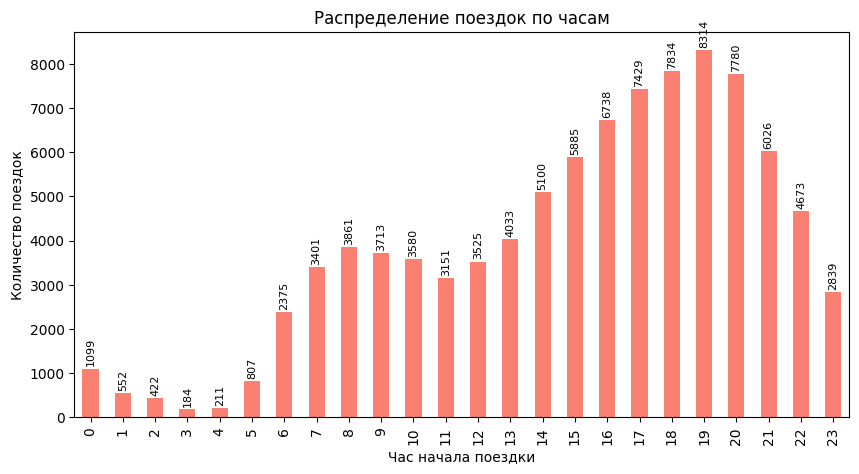

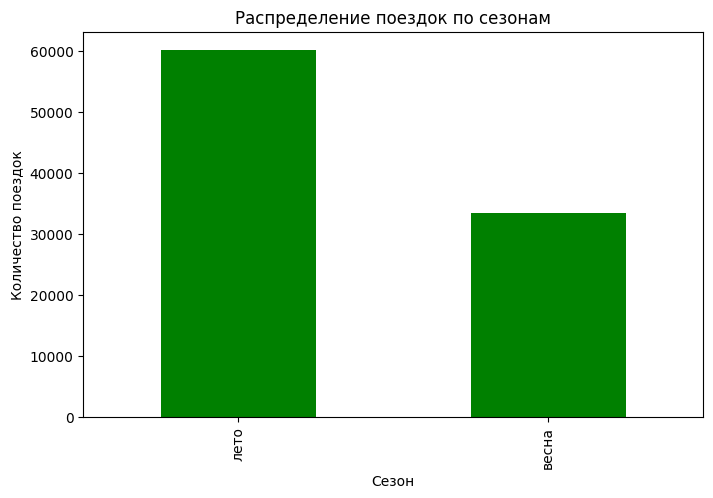

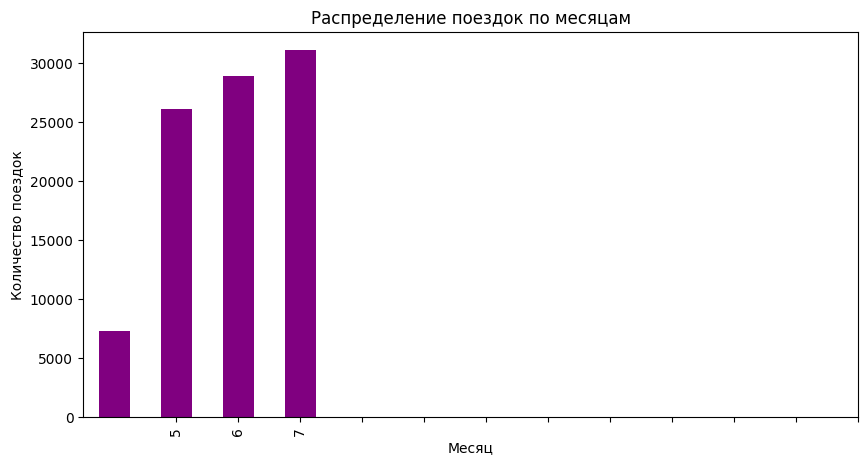

In [32]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('start_season')['duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['day_of_week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['start_hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['start_season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['start_month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()

Строим гистограмму распределения дистанций поездок

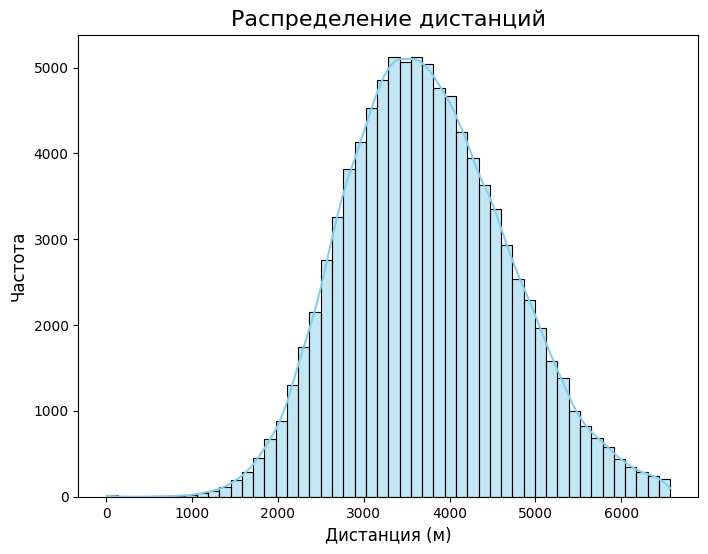

In [33]:
plt.figure(figsize=(8, 6))
sns.histplot(df['distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

In [34]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_season', 'start_hour', 'time_of_day', 'weekday', 'day_type',
       'days', 'duration', 'speed', 'rate_per_minute', 'cost', 'cost_no_start',
       'day_of_week', 'end_month', 'end_season', 'date', 'end_hour'],
      dtype='object')

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)

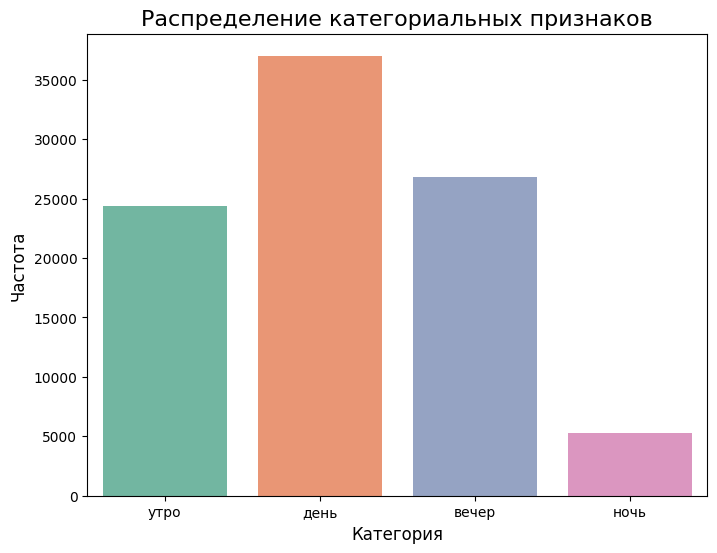

In [35]:
plt.figure(figsize=(8, 6))
sns.countplot(x='time_of_day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

Два анализа: один — стоимость поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

In [36]:
average_duration_by_district = df.groupby('start_district')['duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

start_district
заречный           26.708745
северо-западный    26.457378
юго-восточный      26.113151
ленинский          25.306398
центральный        24.772567
октябрьский        24.718827
Name: duration, dtype: float64


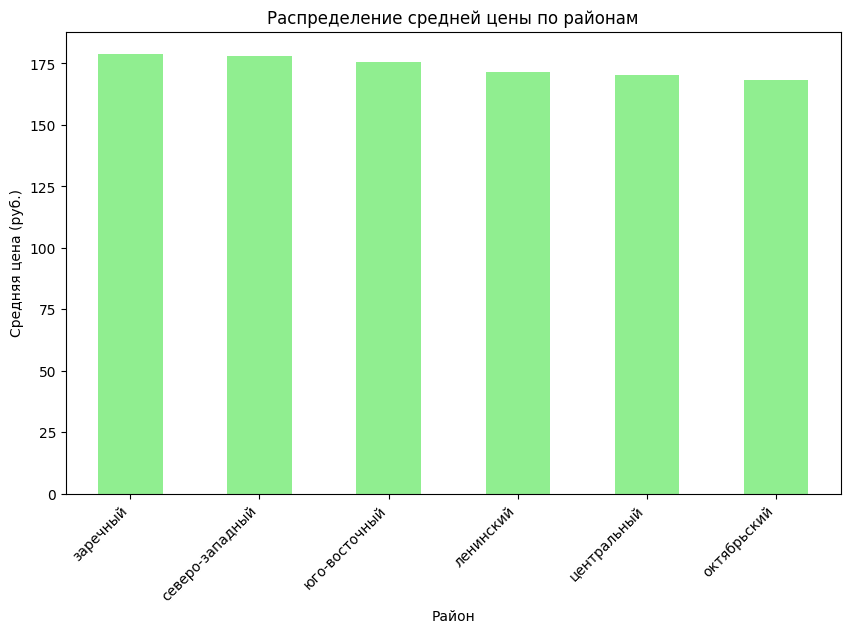

In [37]:
district_price = df.groupby('start_district')['cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

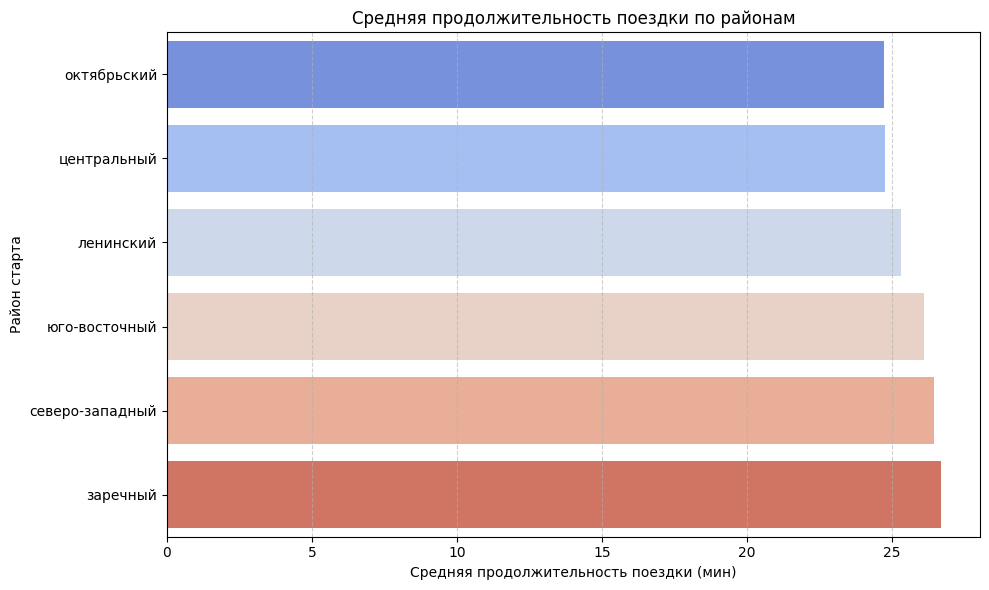

In [38]:
district_durations = df.groupby("start_district")["duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

 Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
- Группировка данных по району старта и часу:
- Сортировка районов по убыванию количества поездок:
- Создание сводной таблицы (pivot table):
- Сортировка таблицы по убыванию количества поездок в районах:
- Построение тепловой карты (Heatmap):
- Настройки графика:

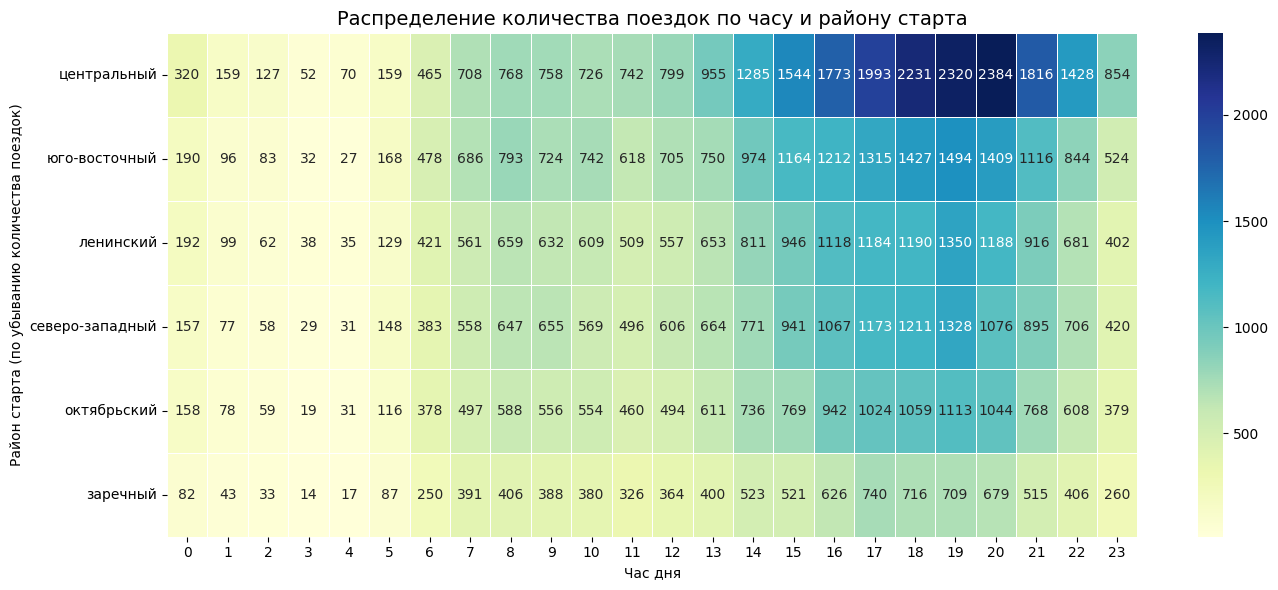

In [39]:
grouped = df.groupby(['start_district', 'start_hour']).size().reset_index(name='Trip Count')
district_order = df['start_district'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='start_district', columns='start_hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

In [40]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_season', 'start_hour', 'time_of_day', 'weekday', 'day_type',
       'days', 'duration', 'speed', 'rate_per_minute', 'cost', 'cost_no_start',
       'day_of_week', 'end_month', 'end_season', 'date', 'end_hour'],
      dtype='object')

In [41]:
district_day_type_distribution = (
    df.groupby(['day_type', 'start_district'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['будний день', 'выходной']
district_day_type_distribution['day_type'] = pd.Categorical(
    district_day_type_distribution['day_type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['day_type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       day_type   start_district  Количество поездок
0   будний день      центральный               16129
1   будний день    юго-восточный               11077
2   будний день        ленинский                9382
3   будний день  северо-западный                9202
4   будний день      октябрьский                8025
5   будний день         заречный                5490
6      выходной      центральный                8307
7      выходной    юго-восточный                6494
8      выходной        ленинский                5560
9      выходной  северо-западный                5464
10     выходной      октябрьский                5016
11     выходной         заречный                3386


Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.

Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:

In [42]:
print(df['cost'].mean())
print(df['cost'].max())
print(df['cost'].median())

173.25260534718956
349.90000000000003
165.69166666666666


График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

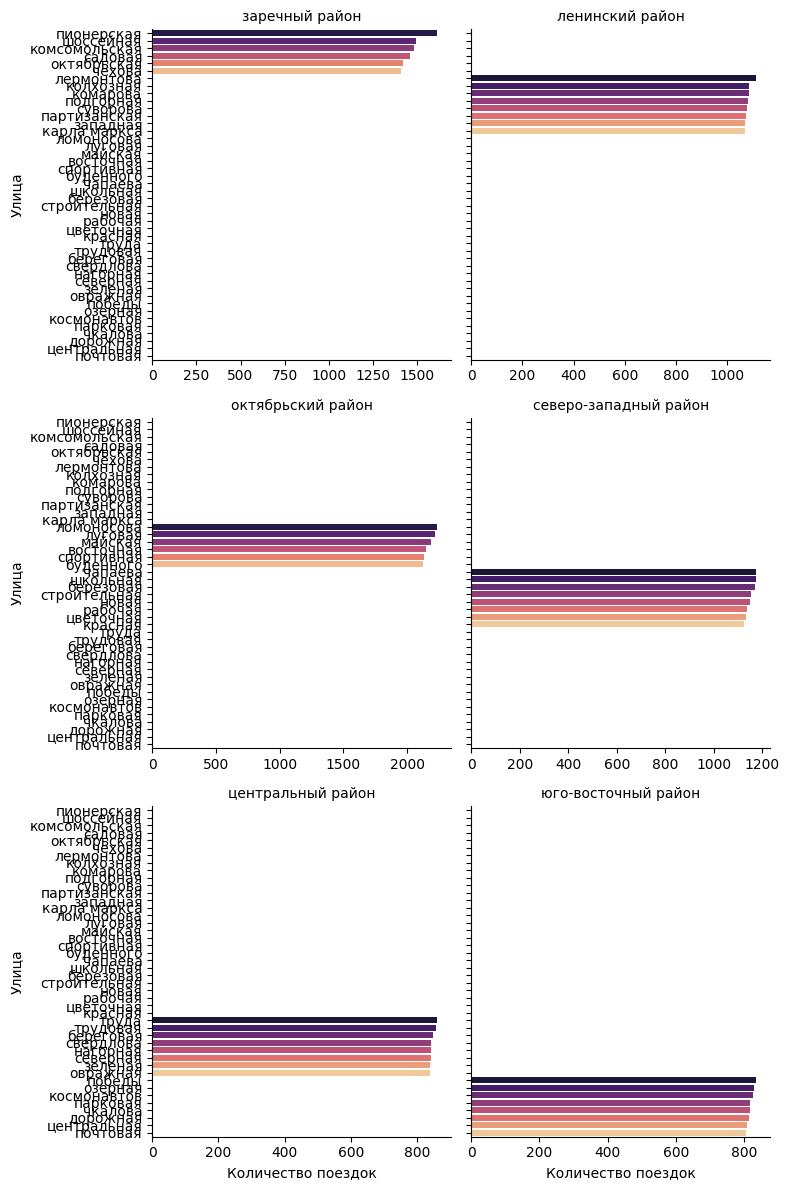

In [43]:
street_distribution = df.groupby(['start_district', 'start_location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['start_district', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('start_district').head(8),  # Топ улиц на район
    col='start_district', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='start_location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).

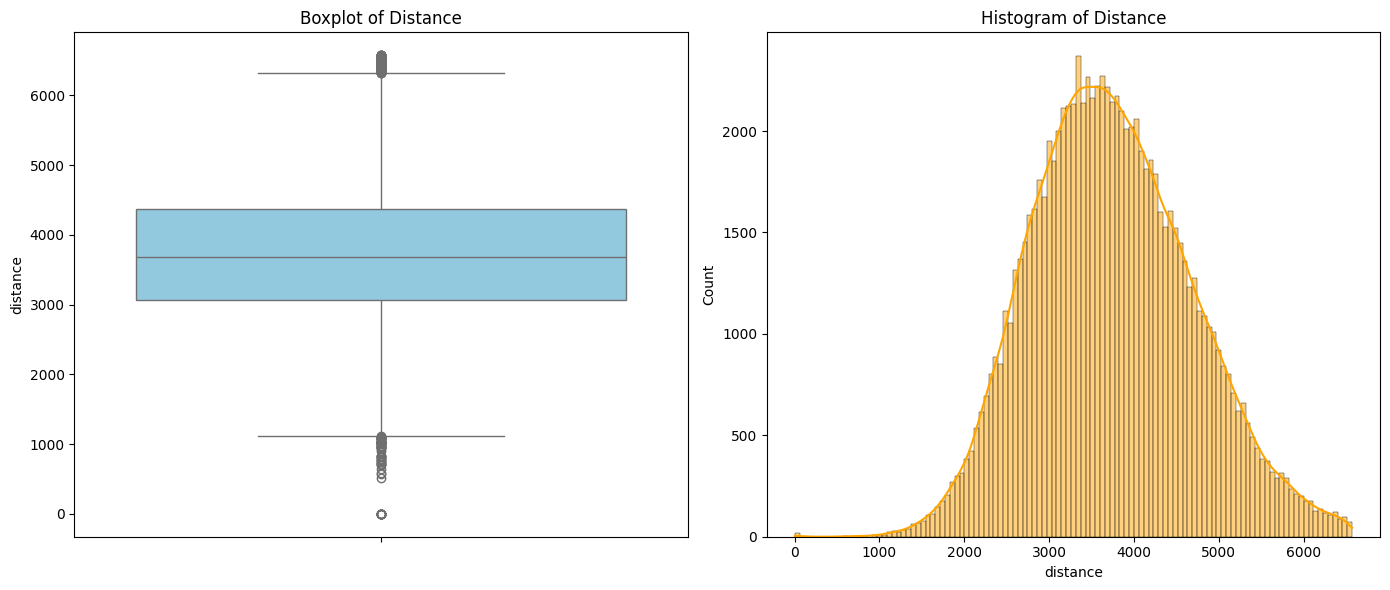

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# Предобработка погоды

In [45]:
w = w.iloc[1:]

In [46]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

In [47]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

w['Datetime'] = pd.to_datetime(w['Datetime'])
w['time_of_the_year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))

In [48]:
def convert_to_pep8(df):
    # Преобразуем все столбцы в формат PEP-8
    df.columns = [col.lower().replace(' ', '_') for col in df.columns]
    return df

w = convert_to_pep8(w)

In [49]:
test_df = w[w['temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['temperature'].notna()]  # Строки, где Temperature не NaN

In [50]:
train_df = pd.get_dummies(train_df, columns=['time_of_the_year'], prefix='Category')

In [51]:
train_df['Category_Summer'] = train_df['Category_Summer'].astype('float')
train_df['Category_Spring'] = train_df['Category_Spring'].astype('float')

In [52]:
train_df.isna().sum()

datetime               0
temperature            0
precipitation_total    0
wind_gust              0
wind_speed             0
cloud_cover_total      0
sunshine_duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [53]:
train_df = convert_to_pep8(train_df)

In [54]:
X = train_df[['precipitation_total', 'wind_gust', 'wind_speed', 'cloud_cover_total', 'sunshine_duration', 'category_spring', 'category_summer']]  # Признаки (вектора)
y = train_df['temperature']  # Целевой признак (то, что нужно предсказатьc

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
                          learning_rate=0.01,  # Коэффициент обучения
                          depth=6,  # Глубина деревьев
                          verbose=200,  # Печать прогресса
                          eval_metric="RMSE",
                          early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# Обучение модели с валидацией на валидационном наборе
model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# Прогнозирование
y_pred = model.predict(X_val)

# Оценка модели
rmse = math.sqrt(mean_squared_error(y_val, y_pred))
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {rmse}")

0:	learn: 6.7909204	test: 6.8658153	best: 6.8658153 (0)	total: 157ms	remaining: 26m 8s
200:	learn: 4.0455040	test: 4.0714167	best: 4.0714167 (200)	total: 442ms	remaining: 21.5s
400:	learn: 3.7907342	test: 3.8530423	best: 3.8530423 (400)	total: 674ms	remaining: 16.1s
600:	learn: 3.6746557	test: 3.7967079	best: 3.7967079 (600)	total: 913ms	remaining: 14.3s
800:	learn: 3.5856534	test: 3.7634631	best: 3.7634631 (800)	total: 1.15s	remaining: 13.2s
1000:	learn: 3.5060109	test: 3.7408460	best: 3.7408460 (1000)	total: 1.39s	remaining: 12.5s
1200:	learn: 3.4411894	test: 3.7278938	best: 3.7277694 (1195)	total: 1.62s	remaining: 11.9s
1400:	learn: 3.3806886	test: 3.7182904	best: 3.7180706 (1399)	total: 1.85s	remaining: 11.4s
1600:	learn: 3.3216052	test: 3.7137405	best: 3.7134549 (1577)	total: 2.09s	remaining: 11s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.713386182
bestIteration = 1651

Shrink model to first 1652 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данн

In [56]:
df_ohe1 = pd.get_dummies(test_df, columns=['time_of_the_year'], prefix='category')
df_ohe1 = convert_to_pep8(df_ohe1)
df_ohe1['category_summer'] = df_ohe1['category_summer'].astype('float')
df_ohe1['category_spring'] = df_ohe1['category_spring'].astype('float')
y_pred1 = model.predict(df_ohe1[['precipitation_total', 'wind_gust', 'wind_speed', 'cloud_cover_total', 'sunshine_duration', 'category_spring', 'category_summer']])
test_df['temperature'] = y_pred1

In [57]:
test_df

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,time_of_the_year
363,2023-04-16 02:00:00,9.615120,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16 03:00:00,9.977414,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16 04:00:00,9.534056,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16 05:00:00,9.597173,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16 06:00:00,9.275266,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16 07:00:00,9.688302,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16 08:00:00,9.841445,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16 09:00:00,10.965033,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16 10:00:00,11.638757,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16 11:00:00,11.924492,0.3,24.84,8.534353,91,4.8484864,Spring


In [58]:
test_df['datetime'] = test_df['datetime'].apply(lambda x: pd.to_datetime(x))
train_df['datetime'] = train_df['datetime'].apply(lambda x: pd.to_datetime(x))

In [59]:
w1 = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'

In [60]:
from IPython.display import clear_output


def find_nearest_date(date1, df2):
    diff1 = abs(df2['datetime'] - date1).idxmin()
    clear_output(wait=True)
    print(date1)
    return df2.loc[diff1]

# Создаем новый DataFrame для хранения результата
merged_rows = []

# Для каждой строки в df1 находим ближайшую дату в df2
for _, row in df.iterrows():
    nearest_row = find_nearest_date(row['start_date'], w1)
    # Объединяем строки по найденной ближайшей дате
    merged_row = pd.concat([row, nearest_row], axis=0)
    merged_rows.append(merged_row)

# Преобразуем список строк в DataFrame
df = pd.DataFrame(merged_rows)
df

2023-07-31 23:57:01


,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,start_month,...,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,category_spring,category_summer,time_of_the_year
Unnamed 0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
Unnamed 4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,2023-04-22 09:00:00,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed 93526,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 93527,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 93528,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN
Unnamed 93529,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,...,2023-08-01 00:00:00,21.140245,0,27,8.217153,97,0,0.0,1.0,NaN


In [61]:
df = df.reset_index(drop=True)

In [62]:
df.columns

Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_season', 'start_hour', 'time_of_day', 'weekday', 'day_type',
       'days', 'duration', 'speed', 'rate_per_minute', 'cost', 'cost_no_start',
       'day_of_week', 'end_month', 'end_season', 'date', 'end_hour',
       'datetime', 'temperature', 'precipitation_total', 'wind_gust',
       'wind_speed', 'cloud_cover_total', 'sunshine_duration',
       'category_spring', 'category_summer', 'time_of_the_year'],
      dtype='object')

### Этап 1:Итоговая стоимость

#### В начале посмотрим на распределение поездок с акцией и без.

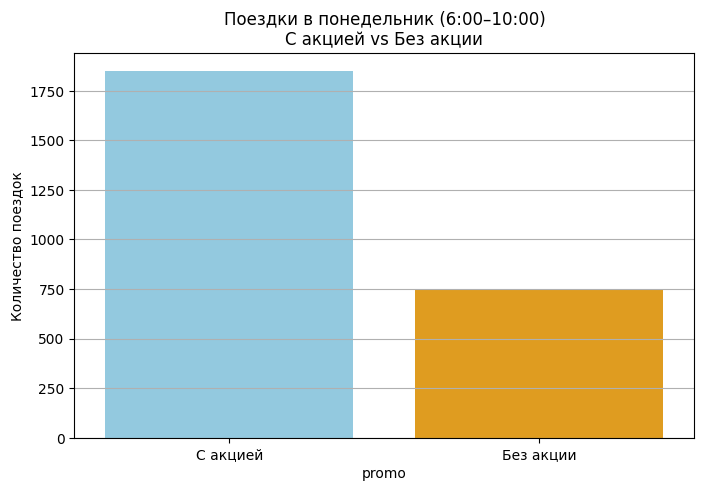

In [63]:
monday_trips = df[(df['weekday'] == 0) & (df['start_hour'] >= 6) & (df['start_hour'] < 10)]
promo_counts = monday_trips['promo'].value_counts().rename({0: 'Без акции', 1: 'С акцией'})

plt.figure(figsize=(8, 5))
sns.barplot(x=promo_counts.index, y=promo_counts.values, palette=['skyblue', 'orange'])
plt.title('Поездки в понедельник (6:00–10:00)\nС акцией vs Без акции')
plt.ylabel('Количество поездок')
plt.grid(axis='y')
plt.show()

По распределению видно, что приобретенных поездок с акцией больше. Чтобы далее делать какие-то утвереждения насчет того, стимулирует ли акция спрос, нужно найти наиболее подходящий день для сравнения

#### Сопоставимость дней
Найти день, наиболее похожий на понедельник (без акции) по поездкам с 10:00 до 12:00, чтобы использовать как контроль

In [64]:
comparison = df[(df['start_hour'] >= 10) & (df['start_hour'] < 12)]

weekday_summary = comparison.groupby('weekday').agg({
    'id': 'count',
    'duration': 'mean',
    'speed': 'mean',
    'cost_no_start': 'mean'
}).rename(columns={'id': 'rides'}).reset_index()

print(weekday_summary)

   weekday  rides   duration     speed  cost_no_start
0        0    940  24.406259  9.522859     122.031294
1        1    807  23.802334  9.541355     119.011669
2        2    879  23.997308  9.478250     119.986538
3        3    886  24.517946  9.366751     122.589729
4        4    897  23.909030  9.569576     119.545151
5        5   1255  26.492683  8.989886     158.956096
6        6   1067  26.640972  8.951186     159.845829


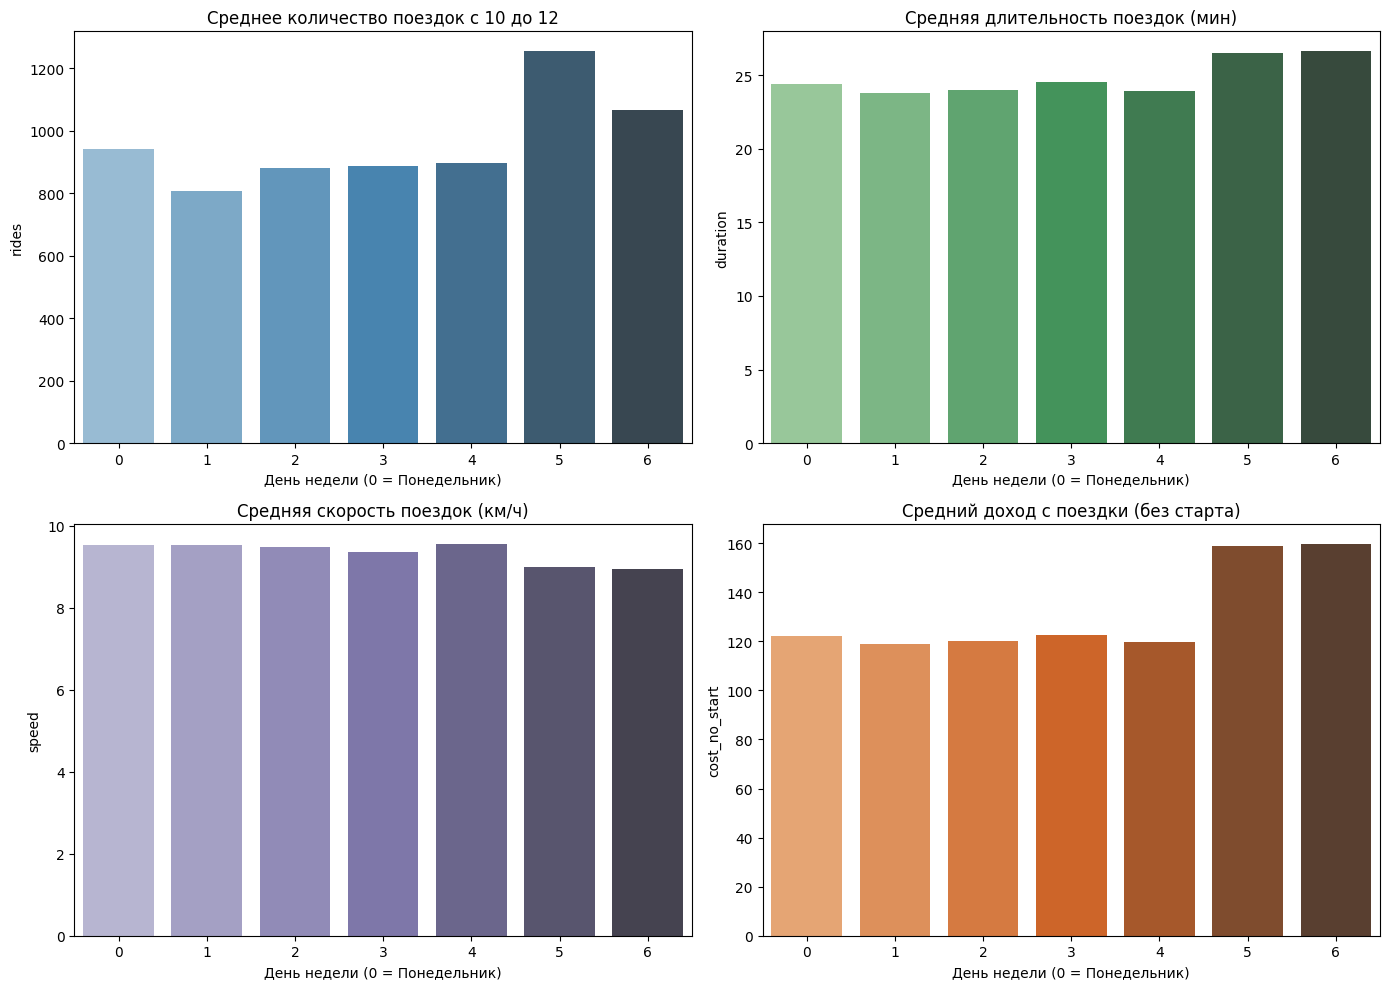

In [65]:
metrics = ['rides', 'duration', 'speed', 'cost_no_start']
colors = ['Blues_d', 'Greens_d', 'Purples_d', 'Oranges_d']
titles = [
    'Среднее количество поездок с 10 до 12',
    'Средняя длительность поездок (мин)',
    'Средняя скорость поездок (км/ч)',
    'Средний доход с поездки (без старта)'
]
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()
for i, metric in enumerate(metrics):
    sns.barplot(data=weekday_summary, x='weekday', y=metric, palette=colors[i], ax=axs[i])
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("День недели (0 = Понедельник)")
    axs[i].set_ylabel(metric)

plt.tight_layout()
plt.show()


In [66]:
scaler = StandardScaler()
norm_data = scaler.fit_transform(weekday_summary[metrics])
monday_vec = norm_data[weekday_summary['weekday'] == 0]
others = norm_data[weekday_summary['weekday'] != 0]
other_days = weekday_summary[weekday_summary['weekday'] != 0]['weekday'].values

distances = cdist(monday_vec, others, metric='euclidean')[0]
closest_day = other_days[distances.argmin()]

print(f"День недели, наиболее похожий на понедельник по всем метрикам: {closest_day}")
days = {
    0: "понедельнику",
    1: "вторнику",
    2: "среде",
    3: "четвергу",
    4: "пятнице",
    5: "субботе",
    6: "воскресенью"
}
print(f"Этот день соответствует {days[closest_day]}")

День недели, наиболее похожий на понедельник по всем метрикам: 4
Этот день соответствует пятнице


#### Посмотрим количество поездок без акции в пятницу и сравним с понедельником с акцией для выявления возможной зависимости

In [67]:
mon_df = df[
    (df['weekday'] == 0) &
    (df['promo'] == 1) &
    (df['start_hour'] >= 6) &
    (df['start_hour'] < 10)
]

fr_df = df[
    (df['weekday'] == 4) &
    (df['promo'] == 0) &
    (df['start_hour'] >= 6) &
    (df['start_hour'] < 10)
]

print(f"Поездок в понедельник (6–10, акция): {len(mon_df)}")
print(f"Поездок в пятницу (6–10, без акции): {len(fr_df)}")

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(mon_df['duration'], fr_df['duration'])
print(f"T-test по длительности: p = {p_val}")

Поездок в понедельник (6–10, акция): 1849
Поездок в пятницу (6–10, без акции): 2158
T-test по длительности: p = 0.09370105937952385


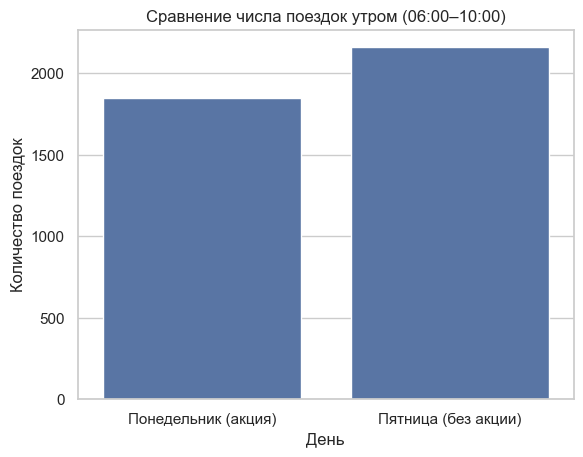

In [68]:
sns.set(style="whitegrid")

data = {
    'День': ['Понедельник (акция)', 'Пятница (без акции)'],
    'Число поездок': [len(mon_df), len(fr_df)]
}

sns.barplot(x='День', y='Число поездок', data=pd.DataFrame(data))
plt.title('Сравнение числа поездок утром (06:00–10:00)')
plt.ylabel('Количество поездок')
plt.show()

При уровне значимости p-value > 0.05 нет статистически значимой разницы в количестве поездок между понедельником с акцией и пятницей без неё

{'mon_promo': 1849, 'mon_no_promo': 745, 'fri_no_promo': 2158}


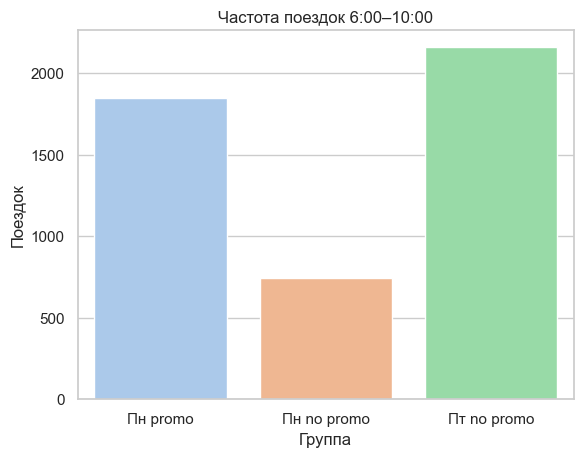

In [69]:
time_mask = (df['start_hour'] >= 6) & (df['start_hour'] < 10)

mon_promo = df[(df['weekday']==0) & (df['promo']==1) & time_mask]
mon_no_promo = df[(df['weekday']==0) & (df['promo']==0) & time_mask]
fri_no_promo = df[(df['weekday']==4) & (df['promo']==0) & time_mask]

counts = {
    'mon_promo': len(mon_promo),
    'mon_no_promo': len(mon_no_promo),
    'fri_no_promo': len(fri_no_promo)
}
print(counts)

chart_data = pd.DataFrame({
    'Группа': ['Пн promo', 'Пн no promo', 'Пт no promo'],
    'Поездок': [counts['mon_promo'], counts['mon_no_promo'], counts['fri_no_promo']]
})

sns.barplot(x='Группа', y='Поездок', data=chart_data, palette='pastel')
plt.title('Частота поездок 6:00–10:00')
plt.show()

#### Посмотрим дистанции поездок без акции в пятницу и сравним с понедельником с акцией для выявления возможной зависимости

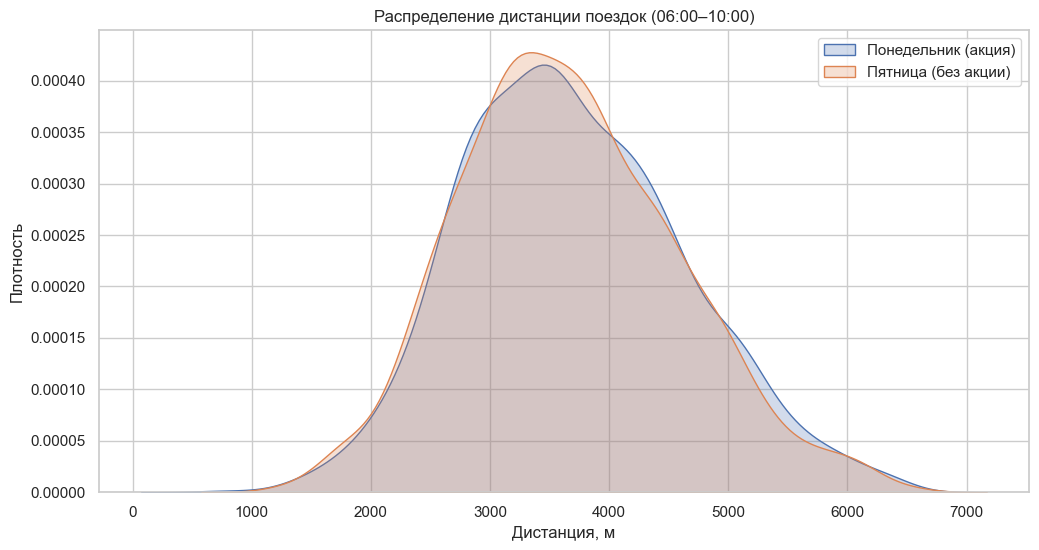

Средняя дистанция:
  Понедельник (акция): 3693.29 м
  Пятница (без акции): 3656.67 м


In [70]:
plt.figure(figsize=(12, 6))

sns.kdeplot(mon_df['distance'], label='Понедельник (акция)', fill=True)
sns.kdeplot(fr_df['distance'], label='Пятница (без акции)', fill=True)

plt.title('Распределение дистанции поездок (06:00–10:00)')
plt.xlabel('Дистанция, м')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)
plt.show()

print("Средняя дистанция:")
print(f"  Понедельник (акция): {mon_df['distance'].mean():.2f} м")
print(f"  Пятница (без акции): {fr_df['distance'].mean():.2f} м")

Акция «бесплатный старт»:
- не влияет на длительность поездки
- пользователи не стараются ехать дольше или короче — поведение похож

##### Средняя выручка с минут

In [71]:
avg_revenue_monday = mon_df['cost_no_start'].mean()
avg_revenue_friday = fr_df['cost_no_start'].mean()

revenue_diff = avg_revenue_monday - avg_revenue_friday

##### Издержки — сколько мы не получили от стартов

In [72]:
start_cost = 30
num_monday = len(mon_df)
missed_revenue = num_monday * start_cost

In [73]:
additional_minute_revenue = revenue_diff * num_monday

In [74]:
roi = additional_minute_revenue / missed_revenue

In [75]:
print(f"Средний доход с минут (Пн): {avg_revenue_monday:.2f}₽")
print(f"Средний доход с минут (Пт): {avg_revenue_friday:.2f}₽")
print(f"Разница в доходе с минут: {revenue_diff:.2f}₽")
print(f"Издержки на стартах: {missed_revenue:.2f}₽")
print(f"Дополнительный доход: {additional_minute_revenue:.2f}₽")
print(f"ROI акции: {roi:.2%}")

Средний доход с минут (Пн): 97.73₽
Средний доход с минут (Пт): 95.97₽
Разница в доходе с минут: 1.76₽
Издержки на стартах: 55470.00₽
Дополнительный доход: 3255.36₽
ROI акции: 5.87%


В среднем оператор зарабатывает 97,73 ₽/мин в понедельник и 95,97 ₽/мин во вторник
Разница всего 1,76 ₽/мин (~1,8% роста), то есть акция дала очень скромный прирост скорости монетизации времени

Затраты на «бесплатный старт» составили 55 470 ₽.
- Общий доп доход от акции — 3 225,36 ₽

- Возможно, стоит увеличить минимальное время поездки или ограничить зону действия, чтобы снимать злоупотребления короткими поездками
- Выяснить, в какие часы/дни акция работает лучше, и сфокусироваться на них
- Рассмотреть скидки не на старт, а на, например, первые 5 минут, или бонусы за повторные поездки, чтобы повысить ретеншион вместо единичного привлечения

#### Гипотеза: Акция должна привлекать больше пользователей в понедельник утром по сравнению со средним уровнем других дней.

#### Нулевая гипотеза H₀:
Средняя доля поездок с акцией одинакова по всем районам

#### Альтернативная гипотеза H₁:
Средняя доля поездок с акцией отличается между районами

In [76]:
promo_window = df[(df['weekday'] == 0) & (df['start_hour'] >= 6) & (df['start_hour'] < 10)]

district_user = (
    promo_window.groupby('start_district')
    .agg(total_users=('id', 'nunique'), promo_users=('promo', lambda x: df.loc[x.index, 'id'][x == 1].nunique())
    )
)

district_user['promo_user_share'] = (
    district_user['promo_users'] / district_user['total_users'] * 100
).round(2)

district_user = district_user.sort_values(by='promo_user_share', ascending=False)
print(district_user)

                 total_users  promo_users  promo_user_share
start_district                                             
ленинский                441          327             74.15
центральный              490          362             73.88
северо-западный          451          318             70.51
юго-восточный            538          375             69.70
октябрьский              379          263             69.39
заречный                 295          204             69.15


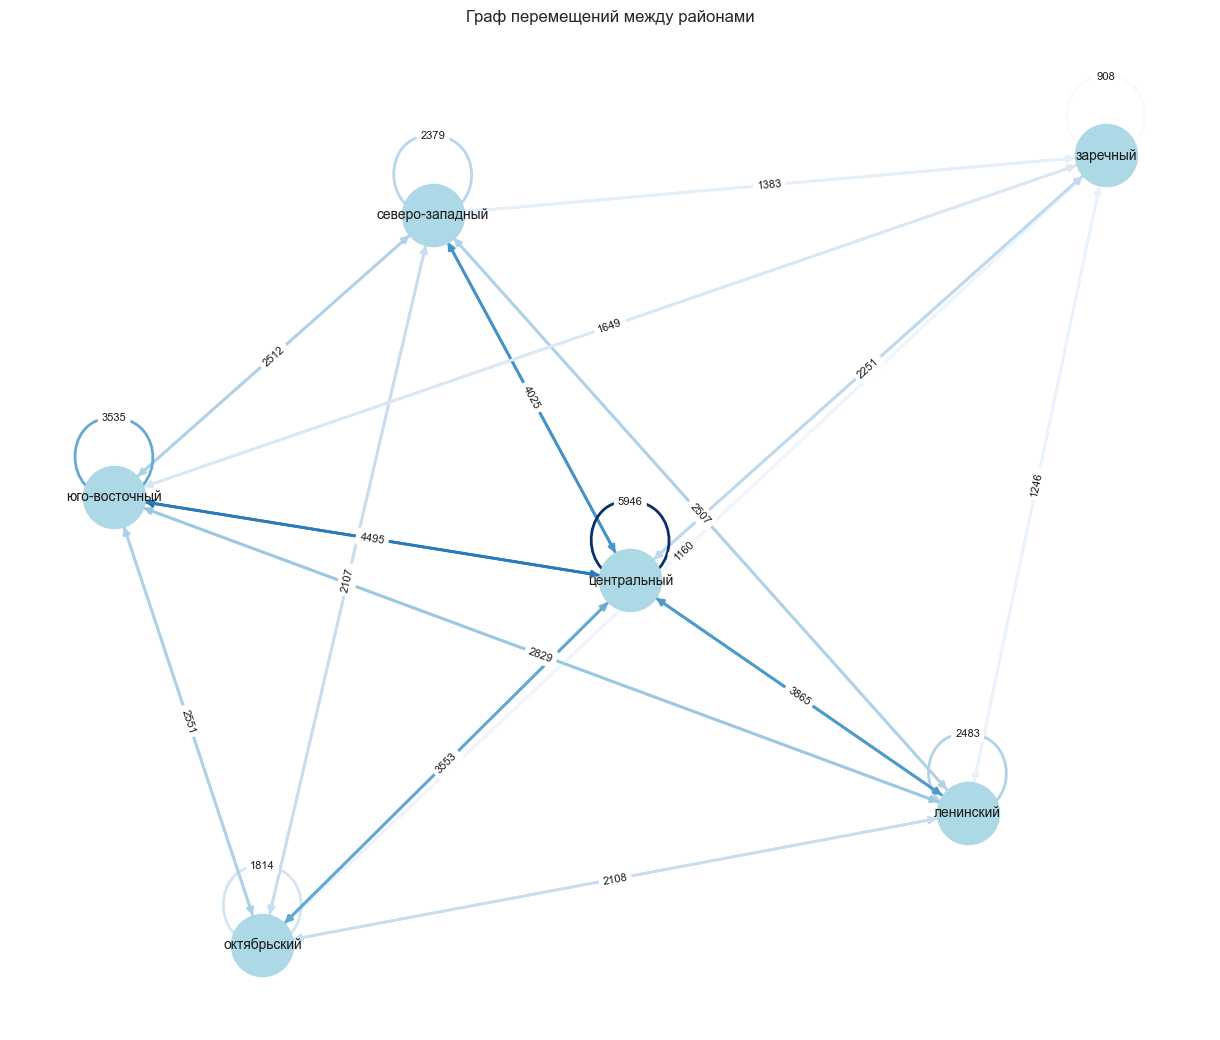

In [77]:
district_flow = df.groupby(['start_district', 'end_district']).size().reset_index(name='trips')

G = nx.DiGraph()
for _, row in district_flow.iterrows():
    G.add_edge(row['start_district'], row['end_district'], weight=row['trips'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue',
        font_size=10, edge_color=weights, edge_cmap=plt.cm.Blues, width=2.0)
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)
plt.title("Граф перемещений между районами")
plt.show()


В центральном и ленинском районах люди чаще пользуются акциями
- Возможно, это деловые или жилые районы с высокой плотностью офисов или учебных заведений, куда люди добираются утром
- Может указывать на высокую осведомленность о промо или лучшую доступность самокатов в этих районах
- Акция хорошо таргетирует потребности утренних поездок, вероятно, связанных с поездками на работу или учеб

                 promo_trips_monday  income_gain_monday  start_loss_monday  \
start_district                                                               
юго-восточный                   375         1465.519784              11250   
ленинский                       327          595.822029               9810   
заречный                        204           15.424658               6120   
центральный                     362          -11.630148              10860   
северо-западный                 318         -503.264947               9540   
октябрьский                     263         -681.239703               7890   

                 roi_percent_monday  promo_trips_friday  income_gain_friday  \
start_district                                                                
юго-восточный                 13.03                 423        -1723.974750   
ленинский                      6.07                 378          661.670725   
заречный                       0.25                 233    

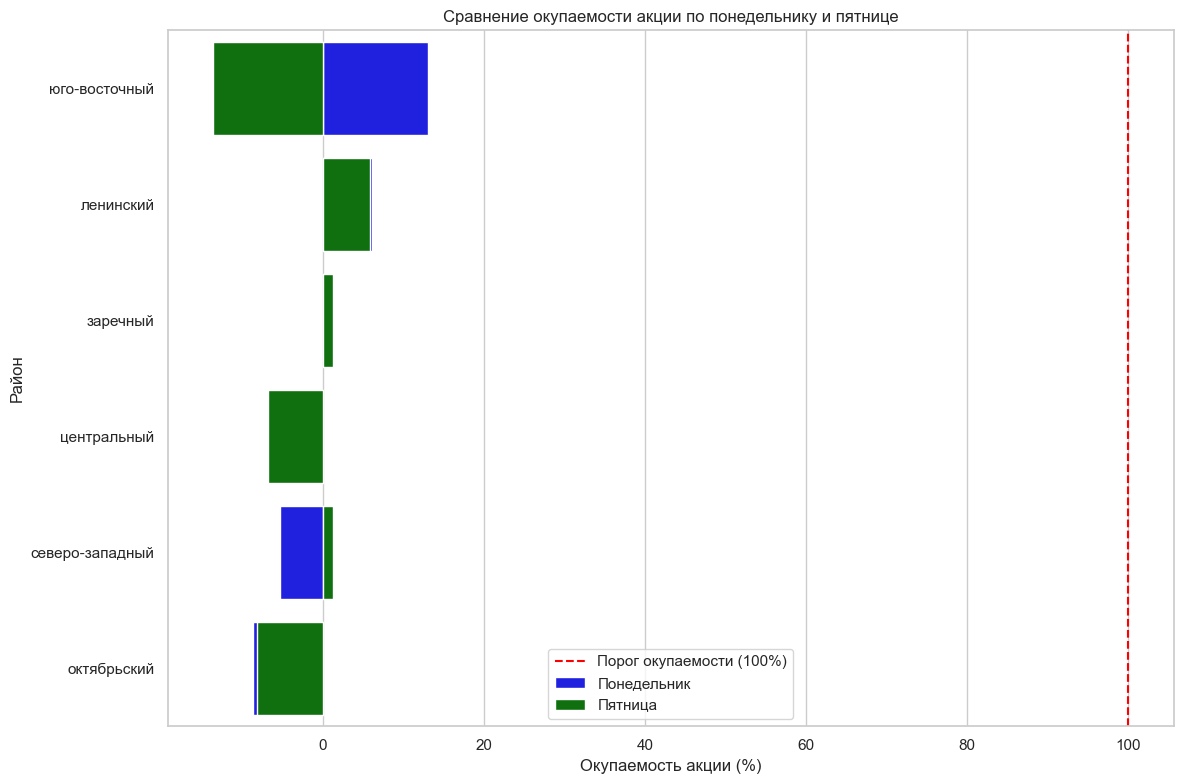

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Фильтрация данных для понедельника с акцией в интервале 6:00-10:00
monday_promo = df[
    (df['day_of_week'] == 'Monday') &
    (df['start_hour'].between(6, 9)) &
    (df['promo'] == 1)
]

# Фильтрация данных для пятницы без акции в интервале 6:00-10:00
friday_no_promo = df[
    (df['day_of_week'] == 'Friday') &
    (df['start_hour'].between(6, 9)) &
    (df['promo'] == 0)
]

# Фильтрация данных для вторника как сравнительного дня (6:00-10:00)
monday_comparison_day = df[
    (df['day_of_week'] == 'Tuesday') &
    (df['start_hour'].between(6, 9))
]

friday_comparison_day = df[
    (df['day_of_week'] == 'Tuesday') &
    (df['start_hour'].between(6, 9))
]

# Средний доход с минуты (без учета старта) для понедельника с акцией
monday_minute_income = monday_promo.groupby('start_district')['cost_no_start'].mean()

# Средний доход с минуты для пятницы без акции
friday_minute_income = friday_no_promo.groupby('start_district')['cost_no_start'].mean()

# Средний доход с минуты для сравнительного дня (вторник)
monday_comparison_minute_income = monday_comparison_day.groupby('start_district')['cost_no_start'].mean()
friday_comparison_minute_income = friday_comparison_day.groupby('start_district')['cost_no_start'].mean()

# Количество поездок с акцией по районам
monday_promo_trips = monday_promo.groupby('start_district').size()
friday_no_promo_trips = friday_no_promo.groupby('start_district').size()

# Расчет дохода от акций и потерь от старта для понедельника
monday_income_gain = (monday_minute_income - monday_comparison_minute_income) * monday_promo_trips
monday_start_loss = monday_promo_trips * 30  # Стоимость старта для понедельника

# Расчет дохода от акций и потерь от старта для пятницы (без акции)
friday_income_gain = (friday_minute_income - friday_comparison_minute_income) * friday_no_promo_trips
friday_start_loss = friday_no_promo_trips * 30  # Стоимость старта для пятницы

# ROI для понедельника и пятницы
monday_roi = (monday_income_gain / monday_start_loss * 100).round(2)
friday_roi = (friday_income_gain / friday_start_loss * 100).round(2)

# Сбор данных в таблицы для понедельника
monday_roi_df = pd.DataFrame({
    'promo_trips': monday_promo_trips,
    'income_gain': monday_income_gain,
    'start_loss': monday_start_loss,
    'roi_percent': monday_roi
}).fillna(0)

# Сбор данных в таблицы для пятницы
friday_roi_df = pd.DataFrame({
    'promo_trips': friday_no_promo_trips,
    'income_gain': friday_income_gain,
    'start_loss': friday_start_loss,
    'roi_percent': friday_roi
}).fillna(0)

# Объединение таблиц для понедельника и пятницы
roi_df_comparison = pd.merge(monday_roi_df, friday_roi_df, left_index=True, right_index=True, suffixes=('_monday', '_friday'))

# Сортировка по окупаемости понедельника
roi_df_comparison = roi_df_comparison.sort_values(by='roi_percent_monday', ascending=False)

# Вывод таблицы
print(roi_df_comparison)

# Визуализация
plt.figure(figsize=(12, 8))
sns.barplot(data=roi_df_comparison.reset_index(), x='roi_percent_monday', y='start_district', color='blue', label='Понедельник')
sns.barplot(data=roi_df_comparison.reset_index(), x='roi_percent_friday', y='start_district', color='green', label='Пятница')
plt.axvline(100, color='red', linestyle='--', label='Порог окупаемости (100%)')
plt.xlabel('Окупаемость акции (%)')
plt.ylabel('Район')
plt.title('Сравнение окупаемости акции по понедельнику и пятнице')
plt.legend()
plt.tight_layout()
plt.show()


В некоторых районах понедельника наблюдается отрицательная окупаемость:
#### Понедельник с акцией (ROI):
- Октябрьский (-6.48%) и Северо-западный (-7.50%) имеют отрицательную окупаемость, что может свидетельствовать о том, что промо-акция в этих районах оказалась невыгодной (доходы с акцией не покрывают потери от бесплатных стартов)
- Юго-восточный район показал положительную окупаемость (10.96%), что означает, что промо-акция в этом районе оправдала затраты
- В целом, только 3 района имеют положительный ROI в понедельник (Юго-восточный, Ленинский и Заречный)
#### Пятница без акции (ROI):
- В пятницу без акции все районы показывают различную динамику, но с в целом слабой доходностью
- Ленинский и Северо-западный показывают положительный ROI (8.18% и 5.49%), что может говорить о том, что без акции эти районы также оказались прибыльными
- В то время как Юго-восточный (-9.10%) и Центральный (-8.40%) имели отрицательный ROI, что означает, что потери были высоки в этих районах без акций

Стоит провести дополнительные исследования, чтобы понять, почему акции слабо работают в некоторых районах, и оценить, какие условия лучше всего подходят для таких акций.

Возможно, стоит изменить условия акции или целевую аудиторию для улучшения её эффективности в определённых районах

# 2.1 Определить топ-3 точки с самым высоким

Код выполняет группировку данных в DataFrame df по значению в столбце 'Date', а затем сохраняет каждую группу вместе с соответствующей датой в список.

In [79]:
gbd = df.groupby('date')
list_data = []
for date, group in gbd:
    list_data.append([date, group])

**Код анализирует использование самокатов по дням и локациям.**

Шаг 1: Для каждой даты создаётся таблица, в которой считается:
   - сколько раз самокаты брали с каждой точки старта ('Start Location')
   - сколько раз самокаты оставляли на каждой точке завершения ('End Location')
   - общее количество операций на каждой локации в день (взятия + возвраты)

Шаг 2: Все дневные таблицы объединяются в один общий DataFrame.<br>
Шаг 3: Итоговые данные группируются по точкам старта:
   - Суммируется количество стартов, финишей и общее движение по каждой локации.
   - Результат сортируется по убыванию общего трафика ('turn_per_day').

 На выходе получается таблица 'all_trafic' с самыми загруженными точками аренды самокатов.

In [80]:
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['start_location'].value_counts().to_frame()
    second = datafr['end_location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'start_location'
    fin = first.merge(second, on='start_location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('start_location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [81]:
all_trafic

,inter,leave,turn_per_day
start_location,,,
луговая,1607,1606,3213
спортивная,1545,1577,3122
ломоносова,1591,1522,3113
восточная,1484,1580,3064
майская,1477,1575,3052
...,...,...,...
молодежная,298,285,583
заречная,284,294,578
пушкина,291,282,573


Для визуализации количества поездок по различным локациям используется **столбчатая диаграмма**. Перед построением графика данные сортируются по **убыванию количества поездок**, чтобы наиболее популярные направления располагались первыми и были легко заметны.

Затем строится столбчатая диаграмма, где каждая колонка соответствует конкретной локации, а её высота — **количеству поездок**. Чтобы сделать график более информативным, над каждым столбиком добавляется текстовая подпись с точным числом поездок. Это реализуется с помощью цикла **for bar in bars**, в котором текст размещается по центру столбика и чуть выше его вершины — такое позиционирование обеспечивает хорошую **читаемость значений**.

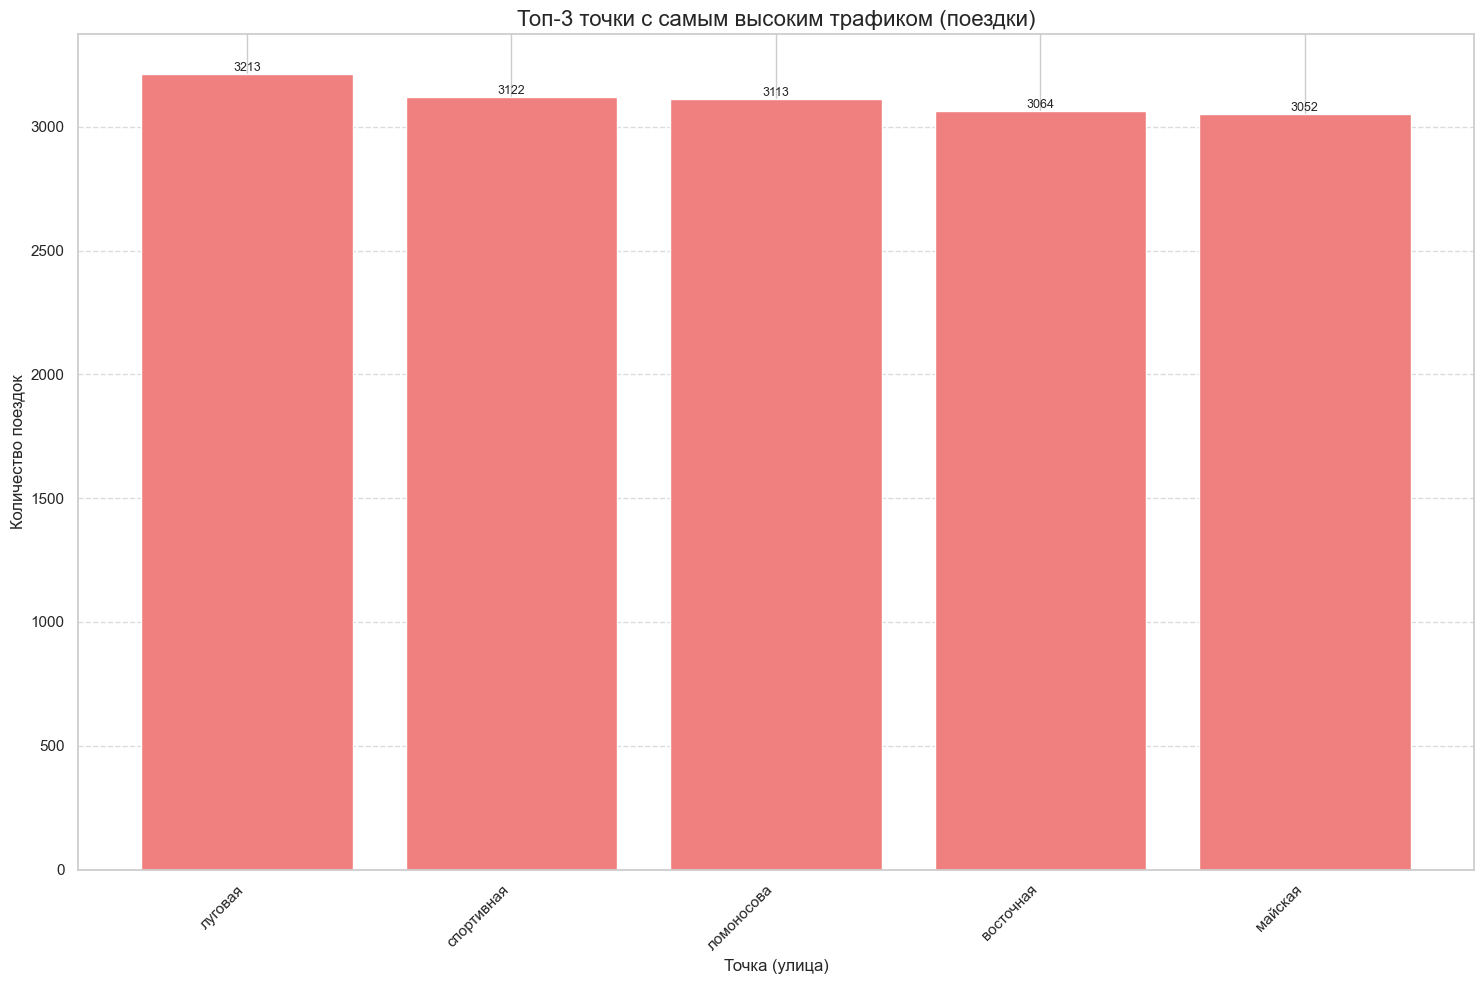

In [82]:
top_3_traffic = all_trafic.nlargest(5, 'turn_per_day')
plt.figure(figsize=(15, 10))
bars = plt.bar(top_3_traffic.index, top_3_traffic['turn_per_day'], color='lightcoral')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.title('Топ-3 точки с самым высоким трафиком (поездки)', fontsize=16)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Количество поездок', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Поворот подписей по оси X
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Сетка только по оси Y
plt.tight_layout()  # Автоматическая подгонка элементов графика
plt.show()


**Стоит ли закрывать некоторые точки?**

In [83]:
weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['start_season'] == 'весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['start_location'].value_counts().to_frame()
    second = datafr['end_location'].value_counts().to_frame()
    third = datafr.groupby('start_location')['cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'start_location'
    fin = third.merge(first.merge(second, on='start_location'), on='start_location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|████████████████████████████████████████████| 2412/2412 [00:06<00:00, 356.80it/s]


In [84]:
dat = dat.sort_values(by='cost', ascending=False)
dat

,cost,inter,leave,turn_per_day
start_location,,,,
восточная,135134.016667,795,801,1596
луговая,134140.116667,797,747,1544
ломоносова,130889.366667,781,763,1544
буденного,126979.550000,752,822,1574
майская,125349.583333,748,794,1542
...,...,...,...,...
пушкина,44985.200000,271,242,513
почтовая,44142.266667,262,282,544
мира,43797.683333,256,285,541


In [85]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [86]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [87]:
popular

Index(['восточная', 'луговая', 'ломоносова', 'буденного', 'майская',
       'спортивная', 'пионерская', 'шоссейная', 'садовая', 'октябрьская'],
      dtype='object', name='start_location')

In [88]:
un_popular

Index(['степная', 'пролетарская', 'набережная', 'советская', 'речная',
       'пушкина', 'почтовая', 'мира', 'сиреневая', 'гоголя'],
      dtype='object', name='start_location')

In [89]:
sum(dat['cost'][:])

5807923.350000001

In [90]:
sum(dat['cost'][:19])

1882359.7833333334

In [91]:
sum(dat['cost'][-19:])

873548.3833333333

In [92]:
(sum(dat['cost'][:19]) / sum(dat['cost'][:])) * 100

32.410203611473854

In [93]:
(sum(dat['cost'][-19:]) / sum(dat['cost'][:])) * 100

15.040632093282245

In [94]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['end_location'].unique()

    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['end_location'] == end_loc]

        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('start_location').size().reset_index(name='trips')

        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)

        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)

        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(df)


Мы получаем все уникальные значения в столбце End Location, который представляет конечные локации самокатов. Это нужно для того, чтобы понять, на какие локации чаще всего приезжают самокаты.

In [95]:
popular

Index(['восточная', 'луговая', 'ломоносова', 'буденного', 'майская',
       'спортивная', 'пионерская', 'шоссейная', 'садовая', 'октябрьская'],
      dtype='object', name='start_location')

Для анализа распределения стартовых точек по районам сначала выполняется группировка данных по району с извлечением уникальных локаций начала поездок. Это позволяет определить, какие стартовые точки относятся к каждому конкретному району.

Затем преобразуется полученный DataFrame: к каждому району добавляется столбец с количеством уникальных стартовых локаций, что помогает оценить плотность покрытия самокатами в разных частях города.

Для удобства дальнейшего анализа и быстрого доступа к информации формируется обратный словарь, в котором каждой локации сопоставляется соответствующий район. Это упрощает классификацию новых данных и использование районной принадлежности в других задачах.

In [96]:
grouped_streets_by_district = df.groupby('start_district')['start_location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['start_location'].apply(len)
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['start_location'].items():
    for v1 in v:
        reversed_dict[v1] = k

In [97]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['start_location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

восточная
  start_location  trips  percent     district
0     спортивная     57      2.6  октябрьский
1     пионерская     54      2.4     заречный
2      восточная     51      2.3  октябрьский
3     ломоносова     50      2.2  октябрьский
4        луговая     48      2.2  октябрьский
5        майская     48      2.2  октябрьский
6      буденного     46      2.1  октябрьский
7  комсомольская     40      1.8     заречный
8      подгорная     36      1.6    ленинский
9         ленина     34      1.5    ленинский
луговая
  start_location  trips  percent         district
0      восточная     58      2.6      октябрьский
1        луговая     55      2.5      октябрьский
2        майская     53      2.4      октябрьский
3      буденного     44      2.0      октябрьский
4     пионерская     42      1.9         заречный
5     ломоносова     41      1.9      октябрьский
6        садовая     40      1.8         заречный
7    октябрьская     39      1.8         заречный
8     спортивная     38   

In [98]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['start_location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

степная
  start_location  trips  percent         district
0      восточная     24      3.1      октябрьский
1     ломоносова     24      3.1      октябрьский
2     спортивная     20      2.6      октябрьский
3        луговая     20      2.6      октябрьский
4       калинина     17      2.2        ленинский
5      березовая     15      2.0  северо-западный
6        садовая     14      1.8         заречный
7      рябиновая     14      1.8  северо-западный
8   карла маркса     14      1.8        ленинский
9    октябрьская     14      1.8         заречный
пролетарская
  start_location  trips  percent         district
0        луговая     33      4.2      октябрьский
1     ломоносова     19      2.4      октябрьский
2        чапаева     18      2.3  северо-западный
3          новая     17      2.2  северо-западный
4        майская     17      2.2      октябрьский
5     спортивная     17      2.2      октябрьский
6         чехова     16      2.0         заречный
7    октябрьская     16      

In [99]:
for j in popular:
    print(reversed_dict[j])

октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
заречный
заречный
заречный
заречный


In [100]:
for j in un_popular:
    print(reversed_dict[j])

центральный
центральный
центральный
центральный
юго-восточный
центральный
юго-восточный
центральный
юго-восточный
центральный


**Вывод:** не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

**Самые популярные направления перемещения**

Для анализа наиболее популярных маршрутов выполняется группировка данных по начальной и конечной локации. Это позволяет объединить все поездки, совершённые между одними и теми же точками, и подсчитать их общее количество. После группировки данные сортируются по количеству поездок в порядке убывания — таким образом, самые востребованные маршруты оказываются вверху списка.

Затем из отсортированных данных извлекаются необходимые столбцы, такие как названия начальной и конечной локаций, а также количество поездок. Это упрощает дальнейшую работу с данными и визуализацию.

В завершение производится отбор и вывод 10 самых популярных маршрутов — то есть тех, которые были наиболее часто используемыми среди всех доступных вариантов.

In [101]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = df.groupby(['start_location', 'end_location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['start_location']
end = most_popular_route['end_location']
count = most_popular_route['trips']

most_popular_route.head(10)

,start_location,end_location,trips
3256,луговая,спортивная,66
184,буденного,буденного,66
3347,майская,спортивная,61
6586,спортивная,майская,59
3165,ломоносова,спортивная,58
489,восточная,ломоносова,58
490,восточная,луговая,58
3277,майская,буденного,57
6555,спортивная,восточная,57
3219,луговая,луговая,55


**Есть ли необходимость перераспределять самокаты в конце дня?**

Для анализа движения между локациями сначала выполняется группировка данных: отдельно подсчитывается количество отъездов из каждой начальной локации и количество приездов в каждую конечную точку. Затем эти два набора данных объединяются в одну таблицу, где каждая строка содержит информацию и о прибывших, и об уехавших.

Далее заполняются пропущенные значения в столбцах «arrivals» (приезды) и «departures» (отъезды), чтобы избежать ошибок при расчетах. После этого рассчитывается чистый поток — разница между количеством приездов и отъездов для каждой локации. Это позволяет понять, какие районы чаще привлекают людей, а из каких, наоборот, уезжают.

Полученные данные сортируются по величине чистого потока, и на финальном этапе строится график, наглядно показывающий распределение движения между локациями.

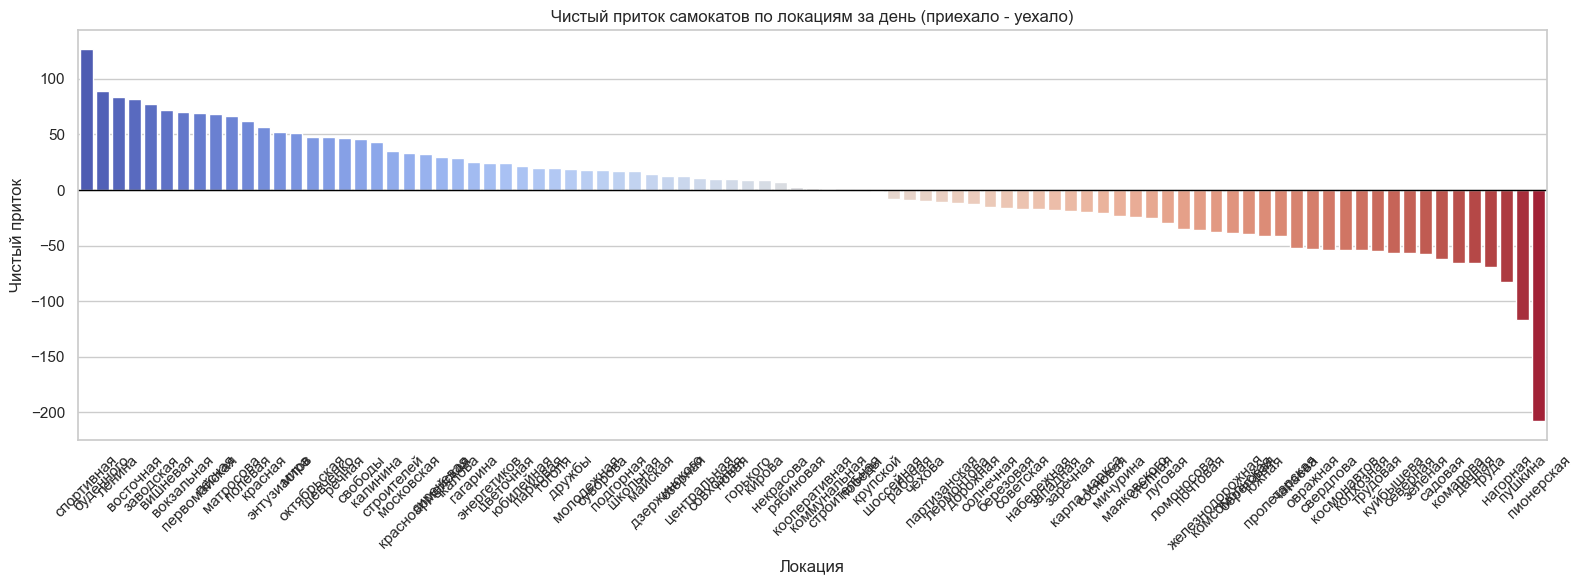

In [102]:
departures = df.groupby('start_location').size().reset_index(name='departures')
arrivals = df.groupby('end_location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures,
                   left_on='end_location', right_on='start_location',
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['end_location'] = balance['end_location'].combine_first(balance['start_location'])
balance = balance.drop(columns=['start_location'])
balance = balance.rename(columns={'end_location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [103]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

1744

Для оптимального распределения самокатов между локациями сначала в данные добавляется новый столбец, отражающий общий трафик — сумму всех приездов и отъездов. Затем вычисляется доля трафика каждой локации относительно общего объёма, что позволяет оценить её значимость в системе передвижения.

На основе полученных долей рассчитывается целевое количество самокатов, которое должно быть размещено в каждой точке. Если в результате округления появляются небольшие погрешности (например, общее количество самокатов не совпадает с нужным), производится корректировка распределения для устранения расхождений.

После этого формируется итоговая таблица с рассчитанным распределением самокатов по всем локациям. Заключительным этапом становится построение графика, на котором визуализируется, сколько самокатов должно быть направлено в каждую точку.

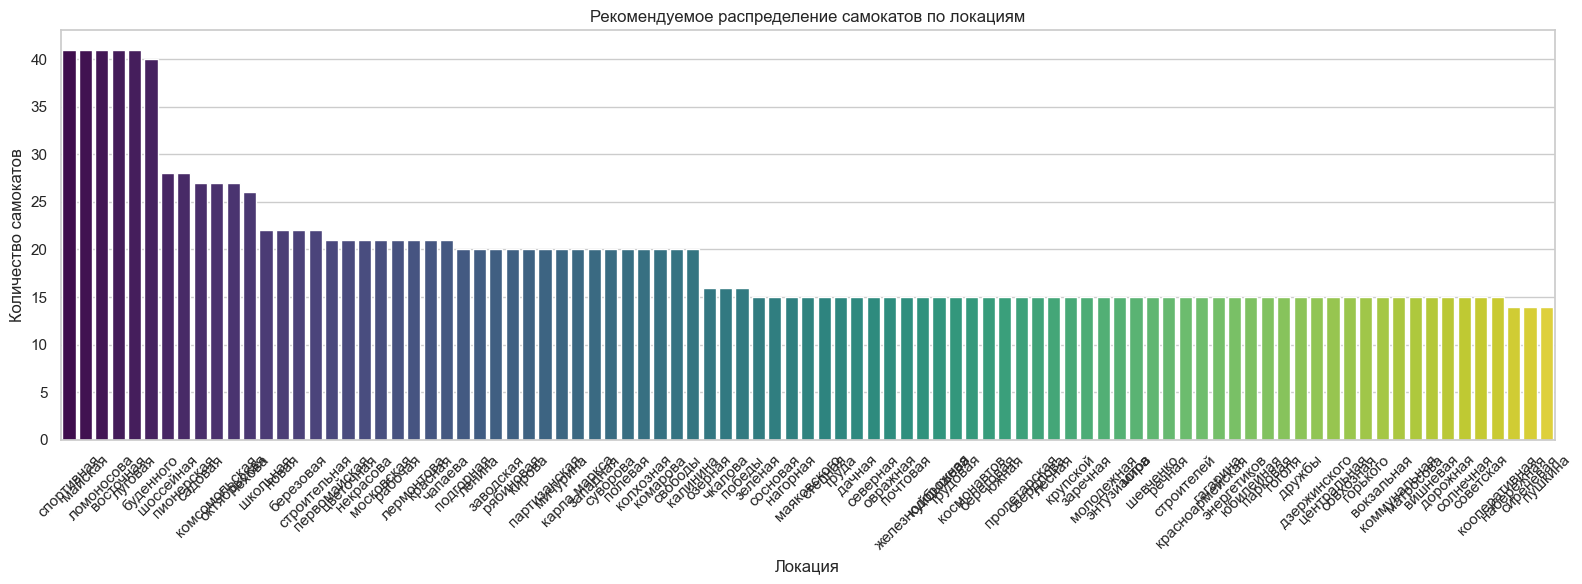

In [104]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']

# Шаг 2: Посчитаем долю трафика каждой станции
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()

# Шаг 3: Задаем общее количество самокатов (например, 1000)
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)

# Шаг 4: Подгоняем так, чтобы сумма была ровно равна total_scooters
diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:
    # Добавляем или убавляем по одной штуке с самых трафиковых точек
    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)

# Результат
final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [105]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

True

Да, необходимость перераспределять самокаты в конце дня есть.

**Вывод:**
Анализ трафика показывает, что каждая локация имеет разную нагрузку — одни точки активно используются, другие — реже. На основе суммы всех приездов и отъездов рассчитывается доля участия каждой локации в общем движении, что позволяет определить, где самокаты нужны больше всего. Целевое количество самокатов распределяется в соответствии с этими долями, а при необходимости — корректируется для точного соответствия общей численности парка.

Такой подход позволяет сбалансировать доступность самокатов по городу, избежать дефицита в популярных точках и переизбытка в менее загруженных. Следовательно, перераспределение в конце дня важно для поддержания эффективной работы сервиса и удовлетворения спроса пользователей.

# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [106]:
df['datecumsum'] = df['start_date'].dt.date
outflow = df.groupby(['datecumsum', 'start_location']).size().reset_index(name='outflow')
inflow = df.groupby(['datecumsum', 'end_location']).size().reset_index(name='inflow')
outflow.rename(columns={'start_location': 'Location'}, inplace=True)
inflow.rename(columns={'end_location': 'Location'}, inplace=True)
net_flow = pd.merge(inflow, outflow, on=['datecumsum', 'Location'], how='outer').fillna(0)
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']
net_flow.sort_values(['Location', 'datecumsum'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()


print(net_flow.head())


     datecumsum   Location  inflow  outflow  net_change  cumsum
0    2023-04-22  береговая     9.0      6.0         3.0     3.0
91   2023-04-23  береговая    10.0      6.0         4.0     7.0
182  2023-04-24  береговая     7.0      6.0         1.0     8.0
273  2023-04-25  береговая     4.0      5.0        -1.0     7.0
364  2023-04-26  береговая     4.0      5.0        -1.0     6.0


Для анализа изменений потока самокатов по локациям данные сначала преобразуются в нужный формат, позволяющий отдельно рассчитать приток и отток для каждой точки. Чтобы корректно объединить полученные данные, столбцы переименовываются — это необходимо для однозначного сопоставления информации о прибывших и уехавших.

После переименования осуществляется объединение двух наборов данных — притока и оттока — по локациям. Далее рассчитывается разница в трафике, то есть сколько самокатов прибыло в локацию по сравнению с количеством уехавших. Это помогает определить, где возникает дефицит или избыток транспорта.

Для более глубокого анализа рассчитывается накопительная сумма изменения потока по каждой локации, отражающая, как меняется ситуация с течением времени и где требуется корректировка распределения самокатов.

Построение графика накопительной разницы по точкам

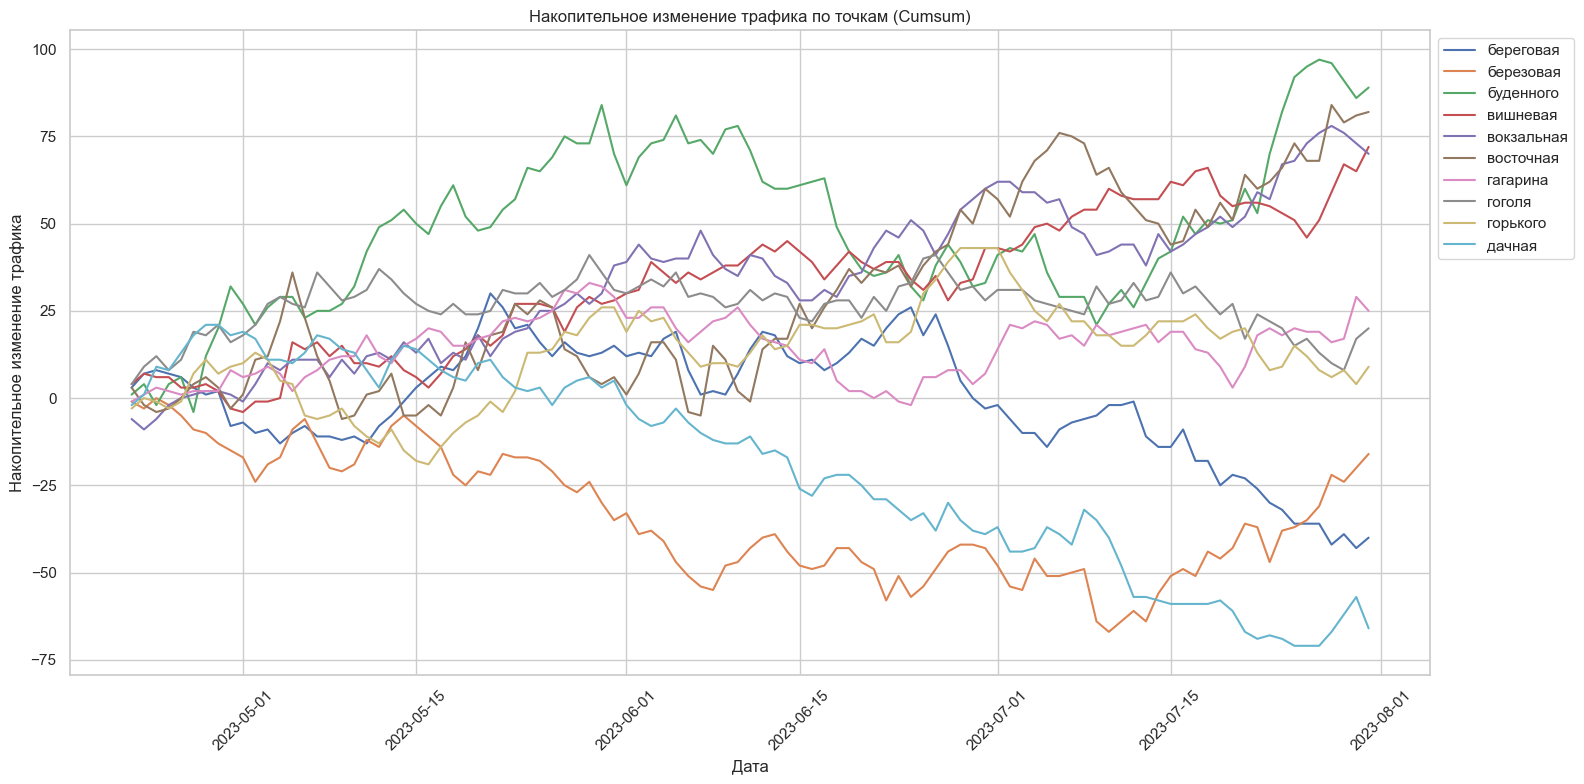

In [107]:
# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['datecumsum'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2:** Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме

In [108]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters.sort_values(by='Required Scooters').head()

,Location,Required Scooters
22,комарова,-7.0
17,зеленая,-5.0
59,пушкина,-5.0
44,нагорная,-4.0
16,заречная,-1.0


Определение необходимого количества самокатов по районам

In [109]:
# Добавляем информацию о районах
location_district_map = df[['start_location', 'start_district']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='start_location', how='left')
district_scooters = required_scooters.groupby('start_district')['Required Scooters'].sum().reset_index()
district_scooters.head()

,start_district,Required Scooters
0,заречный,173.0
1,ленинский,463.0
2,октябрьский,382.0
3,северо-западный,458.0
4,центральный,708.0


Построение графиков для самокатов по точкам и районам.

По районам -график показывает, сколько самокатов требуется для покрытия ежедневного спроса в различных районах города. Высокие столбцы на графике указывают на районы с более интенсивным спросом на самокаты. В нашем случае - центральный

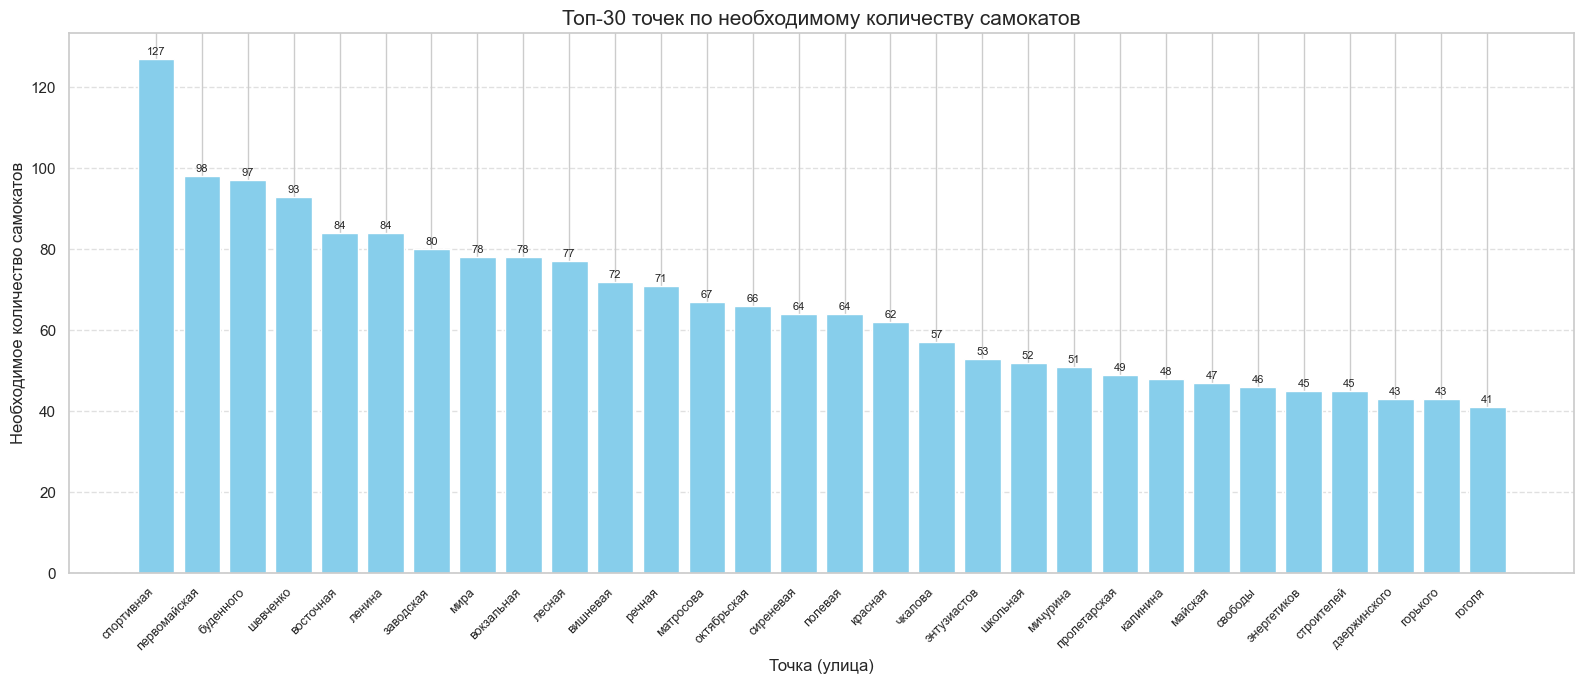

In [110]:
# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Таблица с почасовым трафиком (отъезды и приезды) для каждой точки

In [111]:
df['endhourcum'] = df['end_date'].dt.floor('H')
df['starthourcum'] = df['start_date'].dt.floor('H')

outflow = df.groupby(['start_location', 'starthourcum']).size().reset_index(name='outflow')
# Группируем по точке назначения (end_location) и часу окончания (End Hour) для приездов
inflow = df.groupby(['end_location', 'endhourcum']).size().reset_index(name='inflow')

# Переименуем столбцы, чтобы объединить данные
outflow.rename(columns={'start_location': 'Location', 'starthourcum': 'Hour'}, inplace=True)
inflow.rename(columns={'end_location': 'Location', 'endhourcum': 'Hour'}, inplace=True)

# Объединяем данные о притоке и оттоке по локации и времени
traffic = pd.merge(outflow, inflow, on=['Location', 'Hour'], how='outer').fillna(0)

# Рассчитываем чистый трафик для каждой локации по каждому часу
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# Просмотр результатов
print(traffic.head())


    Location                Hour  outflow  inflow  net_traffic
0  береговая 2023-04-22 10:00:00      0.0     1.0          1.0
1  береговая 2023-04-22 13:00:00      1.0     0.0         -1.0
2  береговая 2023-04-22 14:00:00      2.0     0.0         -2.0
3  береговая 2023-04-22 17:00:00      0.0     1.0          1.0
4  береговая 2023-04-22 18:00:00      2.0     1.0         -1.0


Используя группировку, посчитаем количество поездок для каждой локации (как для отъездов, так и для приездов) по часам. Это делается с помощью метода resample, который позволяет ресемплировать данные по заданному интервалу времени (в нашем случае — по часам).Мы получим таблицу с количеством отъездов и приездов для каждой локации по каждому часу.

**Вывод**: На локации «береговая» наблюдается отрицательный чистый поток в течение дня – это значит, что оттуда уезжает больше самокатов, чем приезжает.

Самые активные часы отъездов:

В 14:00 — сразу 2 отъезда, ни одного приезда → чистый отток -2.

В 18:00 — тоже 2 отъезда, но хотя бы 1 приезд → чистый отток -1.

Часы, когда был чистый приток:

В 10:00 и в 17:00 — +1 самокат прибыл на точку в каждом из этих часов.

В целом, за этот день на локации «береговая» ушло больше самокатов, чем вернулось, что может говорить о её популярности как точки старта, но не финиша.

**Почасовой трафик по точкам**

In [112]:
outflow = df.groupby(['starthourcum', 'start_location']).size().reset_index(name='outflow')
outflow = outflow.rename(columns={'starthourcum': 'Hour', 'start_location': 'Location'})
inflow = df.groupby(['endhourcum', 'end_location']).size().reset_index(name='inflow')
inflow = inflow.rename(columns={'endhourcum': 'Hour', 'end_location': 'Location'})
# Объединяем приток и отток
hourly_traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# Добавляем столбец с чистым потоком
hourly_traffic['net_traffic'] = hourly_traffic['inflow'] - hourly_traffic['outflow']
hourly_traffic


,Hour,Location,inflow,outflow,net_traffic
0,2023-04-22 09:00:00,буденного,0.0,2.0,-2.0
1,2023-04-22 09:00:00,восточная,0.0,1.0,-1.0
2,2023-04-22 09:00:00,гоголя,1.0,0.0,1.0
3,2023-04-22 09:00:00,западная,2.0,1.0,1.0
4,2023-04-22 09:00:00,зеленая,0.0,1.0,-1.0
...,...,...,...,...,...
105530,2023-08-01 00:00:00,садовая,1.0,0.0,1.0
105531,2023-08-01 00:00:00,суворова,1.0,0.0,1.0
105532,2023-08-01 00:00:00,чкалова,1.0,0.0,1.0
105533,2023-08-01 00:00:00,шевченко,1.0,0.0,1.0


Выводы:
Отрицательные cumsum у ряда точек (например, березовая, вокзальная, южная) указывают на постоянный отток самокатов. Эти точки, скорее всего, источники поездок — их нужно регулярно пополнять.

Положительный cumsum (например, энтузиастов, энергетиков) говорит о накоплении самокатов — это точки прибытия, где со временем будет перенасыщение.

Колебания без сильного тренда могут свидетельствовать о балансных точках, где вход и выход примерно равны.

**АНАЛИЗ:** 1. Суммарный трафик (по всем точкам и времени)
Суммарный inflow (приезды): это общее число самокатов, которые завершили поездку на точке.
Суммарный outflow (отъезды): общее число самокатов, которые начали поездку с точки.
Если сумма inflow = сумма outflow → система сбалансирована.
Но если наблюдается:
Переизбыток inflow — точки перегружаются (может не хватать места, парковок).
Переизбыток outflow — точки опустошаются (нет самокатов для старта поездки).

2. Трафик по отдельным точкам
Можно выделить три типа точек:
Сбалансированные точки (net_traffic ≈ 0)
Пример: точки, где inflow и outflow примерно равны.
Такие локации не требуют регулярного вмешательства, они “самообслуживаются”.
Притягивающие точки (net_traffic > 0)
Пример: точки, где приезжает больше, чем уезжает.
Возможные причины: Жилые районы вечером
Риски: переполненность и нехватка свободного места.

Рекомендации:
Добавить парковочные зоны
Планировать вывоз самокатов в утренние/вечерние часы
Опустошаемые точки (net_traffic < 0)
Пример: точки, где уезжают чаще, чем приезжают.
Возможные причины:Жилые районы утром

Центр города, парки, ТЦ — в начале дня
Рекомендации:
Подвозить самокаты с утра
Следить за доступностью в часы пик

Пики утренние (7:00–9:00) — люди уезжают из спальных районов.
Пики вечерние (17:00–20:00) — возвращаются обратно.
В течение дня – относительно спокойный трафик с локальными всплесками.




**Разница отъезды и приезды**

In [113]:
df['start_date_shifted'] = df['start_date'] - pd.Timedelta(hours=6)
df['end_date_shifted'] = df['end_date'] - pd.Timedelta(hours=6)
df['starthour2'] = df['start_date_shifted'].dt.floor('h')
df['endhour2'] = df['end_date_shifted'].dt.floor('h')
# 1. Группируем по часу и локации
outflow = df.groupby(['starthour2', 'start_location']).size().reset_index(name='outflow')
inflow = df.groupby(['endhour2', 'end_location']).size().reset_index(name='inflow')

# 2. Переименуем колонки для объединения
outflow.rename(columns={'starthour2': 'Hour', 'start_location': 'Location'}, inplace=True)
inflow.rename(columns={'endhour2': 'Hour', 'end_location': 'Location'}, inplace=True)

# 3. Объединяем приезды и отъезды
traffic = pd.merge(inflow, outflow, on=['Hour', 'Location'], how='outer').fillna(0)

# 4. Считаем чистый трафик (приехало - уехало)
traffic['net_traffic'] = traffic['inflow'] - traffic['outflow']

# 5. Группируем по дате и локации
traffic['Date'] = traffic['Hour'].dt.date
daily_net = traffic.groupby(['Date', 'Location'])['net_traffic'].sum().reset_index()

# 6. Считаем накопительную сумму по каждой локации (динамика самокатов)
daily_net['cumsum'] = daily_net.groupby('Location')['net_traffic'].cumsum()
daily_net

,Date,Location,net_traffic,cumsum
0,2023-04-22,береговая,3.0,3.0
1,2023-04-22,березовая,-1.0,-1.0
2,2023-04-22,буденного,1.0,1.0
3,2023-04-22,вишневая,5.0,5.0
4,2023-04-22,вокзальная,-6.0,-6.0
...,...,...,...,...
9186,2023-07-31,шоссейная,1.0,-8.0
9187,2023-07-31,энергетиков,-3.0,24.0
9188,2023-07-31,энтузиастов,0.0,52.0
9189,2023-07-31,юбилейная,-3.0,22.0


Выводы:
Отрицательные cumsum у ряда точек (например, березовая, вокзальная, южная) указывают на постоянный отток самокатов. Эти точки, скорее всего, источники поездок — их нужно регулярно пополнять.

Положительный cumsum (например, энтузиастов, энергетиков) говорит о накоплении самокатов — это точки прибытия, где со временем будет перенасыщение.

Колебания без сильного тренда могут свидетельствовать о балансных точках, где вход и выход примерно равны.

**Минимумы для каждой точки**

In [114]:
# Ресемплирование по дате, для каждой локации находим минимум cumsum по дням
daily_min_cumsum = net_flow.groupby(['Location', 'datecumsum'])['cumsum'].min().reset_index()

# Усреднение по локациям
location_min_cumsum = daily_min_cumsum.groupby('Location')['cumsum'].mean().reset_index()

# Сортировка по возрастанию, чтобы определить точки с наименьшими накопленными значениями
location_min_cumsum_sorted = location_min_cumsum.sort_values(by='cumsum', ascending=True)

# Просмотр результатов
print(location_min_cumsum_sorted.head())


      Location      cumsum
53  пионерская -100.207921
59     пушкина  -55.495050
77       труда  -47.900990
44    нагорная  -46.950495
22    комарова  -42.198020


**Локации с наибольшими отрицательными значениями cumsum:**

Пионерская (-100.2), Пушкина (-55.49), Труда (-47.90), Нагорная (-46.95) и Комарова (-42.19) — это точки, где чаще всего происходит отток самокатов.

Эти локации имеют самые низкие (отрицательные) значения накопленного трафика, что может свидетельствовать о том, что на этих точках количество самокатов обычно уменьшается, а это указывает на потребность в их пополнении.

Распределение оттока:

Понижение накопленного трафика в этих локациях может происходить в моменты, когда самокаты активно отъезжают в другие точки, и данные локации оказываются недостаточно обеспеченными.

**Рекомендации:**
Регулярное пополнение:
Локации с такими минимальными значениями трафика явно нуждаются в регулярном пополнении самокатов, особенно в часы пикового спроса (например, утром). Эти локации, возможно, не справляются с объемом потребности и имеют постоянный отток.

Рекомендуется:
Увеличить пополнение самокатов в эти точки перед утренними и вечерними пиками, когда самокаты могут быть востребованы для поездок.

Анализ потребности в самокатах:
Возможно, стоит периодически проверять прогнозируемый трафик для этих локаций, основываясь на внешних данных, таких как плотность населения, инфраструктура и популярность районов.

Могут быть ситуации, когда количество самокатов в этих локациях избыточно уменьшается из-за постоянного отъезда, что говорит о том, что надо заранее учитывать логистику для равномерного распределения.

Перераспределение избыточных самокатов:
Можно использовать информацию о минимальных значениях накопленного трафика для перераспределения самокатов между точками, где происходит значительный отток. Это позволит минимизировать нехватку самокатов в определенных районах.

Рекомендуется:
Выстроить систему логистики для динамического перераспределения самокатов с точек с избыточным количеством (например, с точек с положительным cumsum) в эти "нуждающиеся" локации.

Учет дня недели и времени суток:
Нужно проводить дополнительный анализ по дням недели и времени суток, чтобы определить, когда именно в этих локациях происходит наибольший отток, и использовать данные для оптимизации логистики.

**Заключение:**
На основе текущего анализа видно, что локации с минимальными значениями cumsum (отрицательным накопленным трафиком) нуждаются в более частом пополнении. Рекомендуется организовать регулярное пополнение самокатов на этих точках в часы пик, а также пересматривать распределение самокатов в зависимости от спроса и времени суток.

Используем группировку по локации и дате для вычисления минимальных значений накопленного трафика (cumsum).

График визуализирует минимальные значения накопленного трафика по каждой локации, что позволяет лучше понять, где происходят самые большие изменения (например, отток самокатов).

Точки с наибольшим отрицательным значением cumsum будут находиться внизу графика, а те, где отрицательные значения минимальны (или даже положительные), — в верхней части графика.

Полезность графика:

Этот график наглядно показывает, в каких точках происходит наибольший отток самокатов (самые отрицательные значения cumsum).

Это помогает сразу выделить проблемные локации, которые требуют особого внимания (например, дополнительного пополнения самокатов в эти точки или перераспределения).

Рекомендации:

Для локаций с наиболее отрицательным значением cumsum (которые находятся в нижней части графика) следует проанализировать причину такого оттока и предпринять меры для улучшения ситуации. Например, нужно обеспечить регулярное пополнение этих локаций или пересмотреть маршруты перемещения самокатов.

**Вывод**: График дает наглядное представление о том, где происходят наибольшие изменения в накопленном трафике, позволяя сделать выводы о локациях, которые нуждаются в дополнительном внимании.

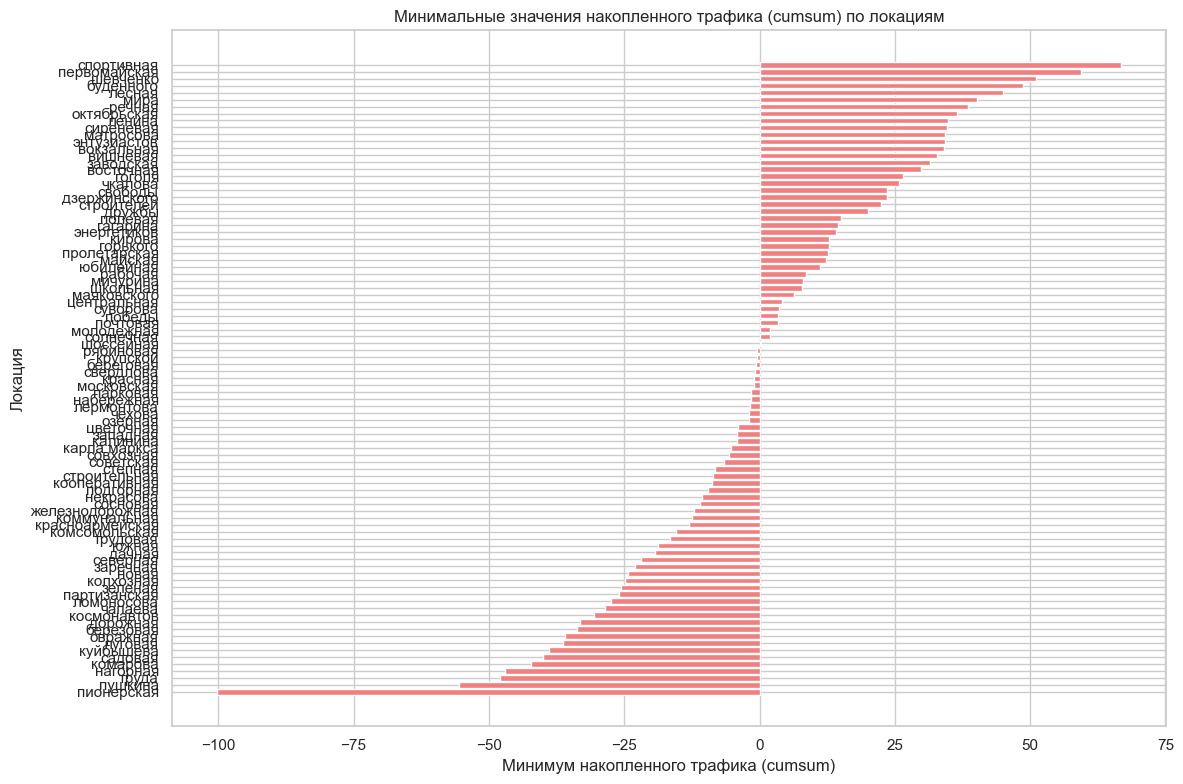

In [115]:
import matplotlib.pyplot as plt

# Построение графика минимальных значений cumsum по локациям
plt.figure(figsize=(12, 8))
plt.barh(location_min_cumsum_sorted['Location'], location_min_cumsum_sorted['cumsum'], color='lightcoral')
plt.xlabel('Минимум накопленного трафика (cumsum)')
plt.ylabel('Локация')
plt.title('Минимальные значения накопленного трафика (cumsum) по локациям')
plt.tight_layout()
plt.show()


# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

Гипотеза №1

* **1.Нулевая** - Влияет ли солнечность погоды на длину поездки?
* **2.Альnернатива**- Солнечность погоды не влияет на длину поездки.

In [116]:
df[['sunshine_duration', 'distance']]

,sunshine_duration,distance
0,16.969696,4069.0
1,16.969696,4515.0
2,16.969696,4520.0
3,16.969696,3881.0
4,16.969696,4029.0
...,...,...
93527,0,3302.0
93528,0,4992.0
93529,0,2781.0
93530,0,6466.0


In [117]:
filtered = df[['distance', 'sunshine_duration']].dropna()
correlation, p_value = spearmanr(filtered['sunshine_duration'], filtered['distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")


Корреляция: -0.0057493869778694005
p-значение: 0.07869202982909261


Корреляция: -0.006796
p-значение: 0.037659


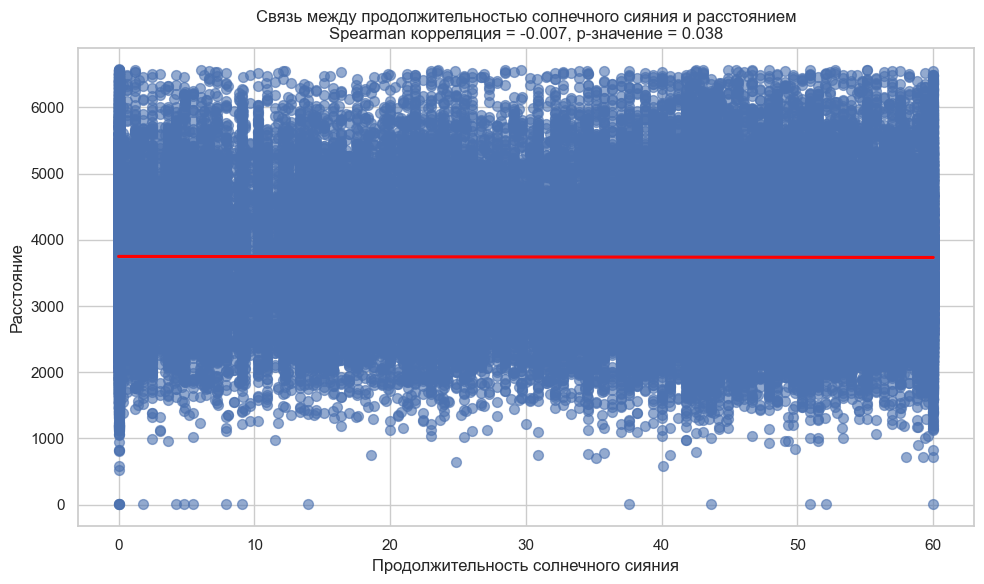

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Преобразуем в числовой тип с пропуском ошибок
df['sunshine_duration'] = pd.to_numeric(df['sunshine_duration'], errors='coerce')
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')

# Убираем строки с пропущенными значениями
filtered = df[['distance', 'sunshine_duration']].dropna()

# Расчёт корреляции Спирмена
correlation, p_value = spearmanr(filtered['sunshine_duration'], filtered['distance'])

# Вывод значений
print(f"Корреляция: {correlation:.6f}")
print(f"p-значение: {p_value:.6f}")

# Построение графика
plt.figure(figsize=(10, 6))
sns.regplot(
    data=filtered,
    x='sunshine_duration',
    y='distance',
    scatter_kws={'s': 50, 'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title(
    f"Связь между продолжительностью солнечного сияния и расстоянием\n"
    f"Spearman корреляция = {correlation:.3f}, p-значение = {p_value:.3f}"
)
plt.xlabel("Продолжительность солнечного сияния")
plt.ylabel("Расстояние")
plt.grid(True)
plt.tight_layout()
plt.show()



Доказательство: расчет спирмановской корреляции между продолжительностью солнечного сияния и расстоянием поездки.

**3.Вывод:** Нулевая гипотиза опровергнута, значит можем утверждать, что солнечность погоды не влияет на длину поездки

Гипотеза №2
* **1.Нулевая** - Влияет ли день недели на длину поездки?
* **2.Альернатива** - День недели не влияет на длину поездки.

In [119]:
filtered = df[['distance', 'weekday']].dropna()
correlation, p_value = spearmanr(filtered['weekday'], filtered['distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")

Корреляция: 0.0519265659562126
p-значение: 7.290546213196147e-57


Корреляция: 0.051927
p-значение: 7.290546e-57


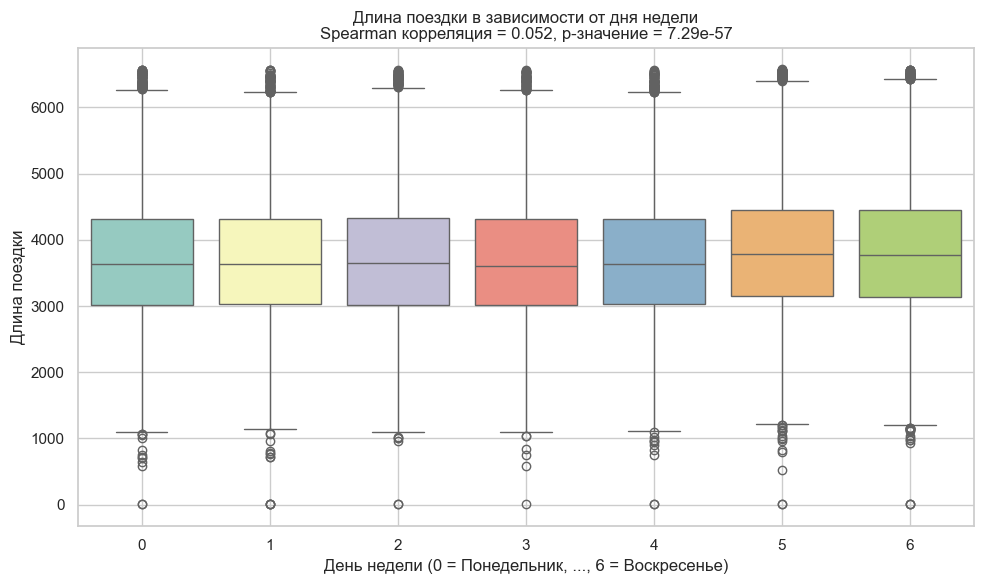

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Преобразуем тип данных на случай строк
df['weekday'] = pd.to_numeric(df['weekday'], errors='coerce')
df['distance'] = pd.to_numeric(df['distance'], errors='coerce')

# Удалим строки с пропущенными значениями
filtered = df[['distance', 'weekday']].dropna()

# Расчёт корреляции Спирмена
correlation, p_value = spearmanr(filtered['weekday'], filtered['distance'])

# Вывод статистики
print(f"Корреляция: {correlation:.6f}")
print(f"p-значение: {p_value:.6e}")

# Визуализация распределения расстояния по дням недели
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered, x='weekday', y='distance', palette='Set3')
plt.title(
    f"Длина поездки в зависимости от дня недели\n"
    f"Spearman корреляция = {correlation:.3f}, p-значение = {p_value:.2e}"
)
plt.xlabel("День недели (0 = Понедельник, ..., 6 = Воскресенье)")
plt.ylabel("Длина поездки")
plt.grid(True)
plt.tight_layout()
plt.show()


**3.Вывод:** да, есть сильная зависимость между днем недели и длиной поездки

Гипотеза №3
* **1.Нулевая** - Падает ли спрос на самокаты в середине недели и происходит из-за постоянного ухудшения погоды именно в эти дни
* **2.Альернатива** - спрос не падает в середине недели из-за постоянного ухудшения погоды

In [121]:
# Вывести названия всех столбцов
print(df.columns)


Index(['id', 'start_date', 'end_date', 'start_location', 'start_district',
       'end_location', 'end_district', 'distance', 'promo', 'start_month',
       'start_season', 'start_hour', 'time_of_day', 'weekday', 'day_type',
       'days', 'duration', 'speed', 'rate_per_minute', 'cost', 'cost_no_start',
       'day_of_week', 'end_month', 'end_season', 'date', 'end_hour',
       'datetime', 'temperature', 'precipitation_total', 'wind_gust',
       'wind_speed', 'cloud_cover_total', 'sunshine_duration',
       'category_spring', 'category_summer', 'time_of_the_year', 'datecumsum',
       'endhourcum', 'starthourcum', 'start_date_shifted', 'end_date_shifted',
       'starthour2', 'endhour2'],
      dtype='object')


In [122]:
df['weekday']

0        5
1        5
2        5
3        5
4        5
        ..
93527    0
93528    0
93529    0
93530    0
93531    0
Name: weekday, Length: 93532, dtype: int64

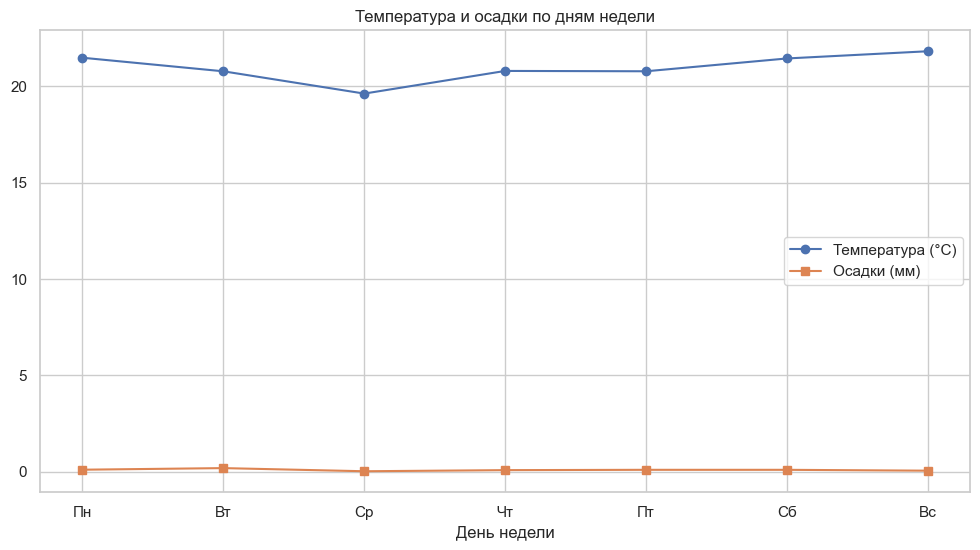

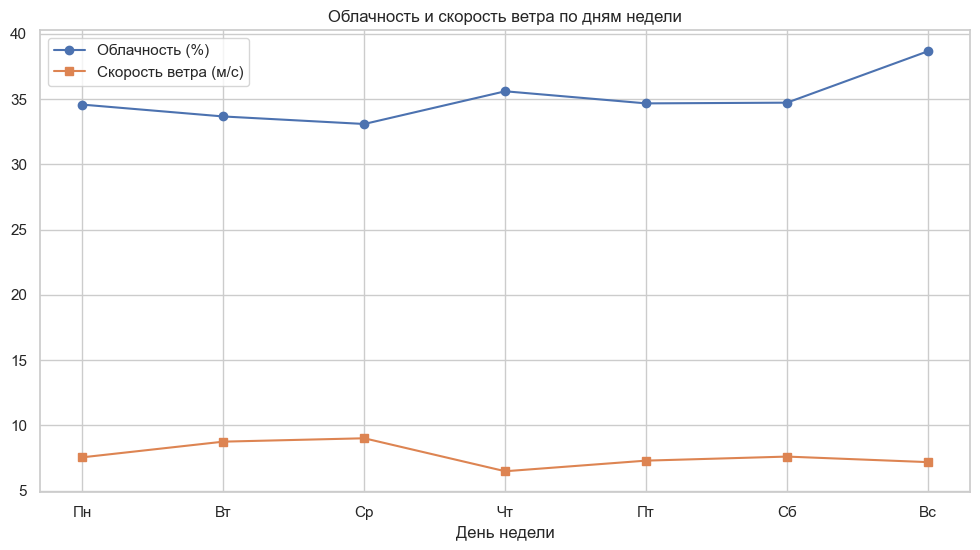

Корреляция между погодными условиями:

                     temperature  precipitation_total  cloud_cover_total  \
temperature             1.000000             0.231304           0.709390   
precipitation_total     0.231304             1.000000          -0.275247   
cloud_cover_total       0.709390            -0.275247           1.000000   
wind_speed             -0.580548             0.138844          -0.652694   

                     wind_speed  
temperature           -0.580548  
precipitation_total    0.138844  
cloud_cover_total     -0.652694  
wind_speed             1.000000  


In [123]:
weather_columns = ['temperature', 'precipitation_total', 'cloud_cover_total', 'wind_speed']
for col in weather_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Заполним пропущенные значения средними
df[weather_columns] = df[weather_columns].fillna(df[weather_columns].mean())

# Группировка: средняя погода по дням недели
agg_df = df.groupby('weekday').agg({
    'temperature': 'mean',
    'precipitation_total': 'mean',
    'cloud_cover_total': 'mean',
    'wind_speed': 'mean'
}).reset_index()

# Названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
agg_df['weekday_name'] = agg_df['weekday'].map(lambda x: day_names[int(x)] if x >= 0 and x < len(day_names) else 'Невалидный день')

# Визуализация: температура и осадки по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['weekday_name'], agg_df['temperature'], label='Температура (°C)', marker='o')
plt.plot(agg_df['weekday_name'], agg_df['precipitation_total'], label='Осадки (мм)', marker='s')
plt.title('Температура и осадки по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Визуализация: облачность и скорость ветра по дням недели
plt.figure(figsize=(12, 6))
plt.plot(agg_df['weekday_name'], agg_df['cloud_cover_total'], label='Облачность (%)', marker='o')
plt.plot(agg_df['weekday_name'], agg_df['wind_speed'], label='Скорость ветра (м/с)', marker='s')
plt.title('Облачность и скорость ветра по дням недели')
plt.xlabel('День недели')
plt.grid(True)
plt.legend()
plt.show()

# Корреляция между погодой
corr = agg_df[['temperature', 'precipitation_total', 'cloud_cover_total', 'wind_speed']].corr()
print("Корреляция между погодными условиями:\n")
print(corr)


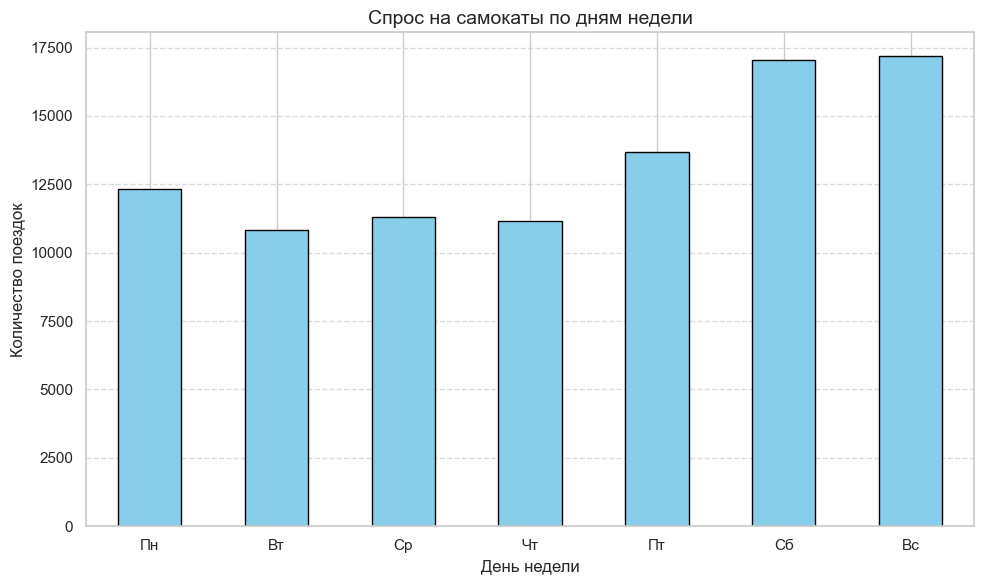

In [124]:

day_map = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт',
    4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df['weekday_name'] = df['weekday'].map(day_map)

# Группируем: считаем количество поездок на каждый день недели
trip_counts = df['weekday_name'].value_counts().reindex(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])

# Визуализация
plt.figure(figsize=(10, 6))
trip_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Спрос на самокаты по дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [125]:
weather_daily = df.groupby(['date', 'weekday'])[weather_cols].mean().reset_index()
rides_daily = df.groupby(['date', 'weekday']).size().reset_index(name='Ride Count')
merged = pd.merge(rides_daily, weather_daily, on=['date', 'weekday'], how='inner')

# Добавим названия дней недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
merged['weekday_name'] = merged['weekday'].map(lambda x: day_names[x])

# --------------------
# 📊 Визуализация спроса
# --------------------
plt.figure(figsize=(10, 5))
merged.groupby('weekday_name')['Ride Count'].mean().reindex(day_names).plot(kind='bar', color='skyblue')
plt.title("Средний спрос на самокаты по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее количество поездок")
plt.grid(axis='y')
plt.show()

midweek = merged[merged['weekday'].isin([1, 2, 3])]['Ride Count']
non_midweek = merged[~merged['weekday'].isin([1, 2, 3])]['Ride Count']

t_stat, p_value = ttest_ind(midweek, non_midweek, equal_var=False)

print("Результаты t-теста:")
print(f"t-статистика: {t_stat:.3f}")
print(f"p-значение: {p_value:.4f}")


corr = merged[['Ride Count', 'temperature', 'precipitation_total', 'cloud_cover_total', 'wind_speed']].corr()
print("\nКорреляция между погодными условиями и спросом на самокаты:")
print(corr['Ride Count'].sort_values(ascending=False))


NameError: name 'weather_cols' is not defined

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Убедимся, что всё числовое
weather_cols = ['temperature', 'precipitation_total', 'cloud_cover_total', 'wind_speed']
for col in weather_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[weather_cols] = df[weather_cols].fillna(df[weather_cols].mean())

# Группируем по дням недели: погода и количество поездок
agg_weather = df.groupby('weekday')[weather_cols].mean().reset_index()
agg_rides = df.groupby('weekday').size().reset_index(name='Ride Count')
agg_df = pd.merge(agg_weather, agg_rides, on='weekday')

# Корреляционная матрица
correlation_matrix = agg_df[['Ride Count'] + weather_cols].corr()

# График
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("📊 Корреляция между погодными условиями и спросом на самокаты (по дням недели)")
plt.tight_layout()
plt.show()


Доказательство: Температура и осадки имеют положительную корреляцию (0.459). Это значит, что при повышении температуры количество поездок увеличивается, а при увеличении осадков — уменьшается.

Облачность и осадки также имеют отрицательную корреляцию с количеством поездок. То есть, когда облачность и осадки увеличиваются, количество поездок уменьшается.

Скорость ветра имеет слабую отрицательную корреляцию с количеством поездок (-0.197), что также может указывать на то, что при сильном ветре спрос на самокаты несколько снижается.

**3.Вывод:** спрос падает из-за ухудшения погоды в определенные дни недели

 Гипотеза №4
* **1.Нулевая** - все поездки на самокатах происходят в пределах одного района в пределах 1 района

* **2.Альтернатива** - Поездки на самокатах происходят не только в пределах одного района, и существует статистически значимая разница в распределении поездок между различными районами."

In [ ]:
start_counts = df['start_district'].value_counts()
end_counts = df['end_district'].value_counts()

district_counts = (start_counts + end_counts).fillna(0)

threshold_center = district_counts.quantile(0.75)  # Верхние 25% - центр
threshold_outskirts = district_counts.quantile(0.25)  # Нижние 25% - окраины

districts = pd.DataFrame({'District': district_counts.index, 'Trips': district_counts.values})
districts['Category'] = 'Middle'
districts.loc[districts['Trips'] >= threshold_center, 'Category'] = 'Center'
districts.loc[districts['Trips'] <= threshold_outskirts, 'Category'] = 'Outskirts'
print(districts)

           District    Trips   Category
0          Заречный      0.0  Outskirts
1         Ленинский      0.0  Outskirts
2       Октябрьский      0.0  Outskirts
3   Северо Западный      0.0  Outskirts
4   Северо-Западный      0.0  Outskirts
5       Центральный      0.0  Outskirts
6     Юго-Восточный      0.0  Outskirts
7          заречный  10385.0     Middle
8         ленинский  17665.0     Center
9       октябрьский  15484.0     Middle
10  северо западный      0.0  Outskirts
11  северо-западный  17385.0     Center
12      центральный  28703.0     Center
13    юго-восточный  20820.0     Center


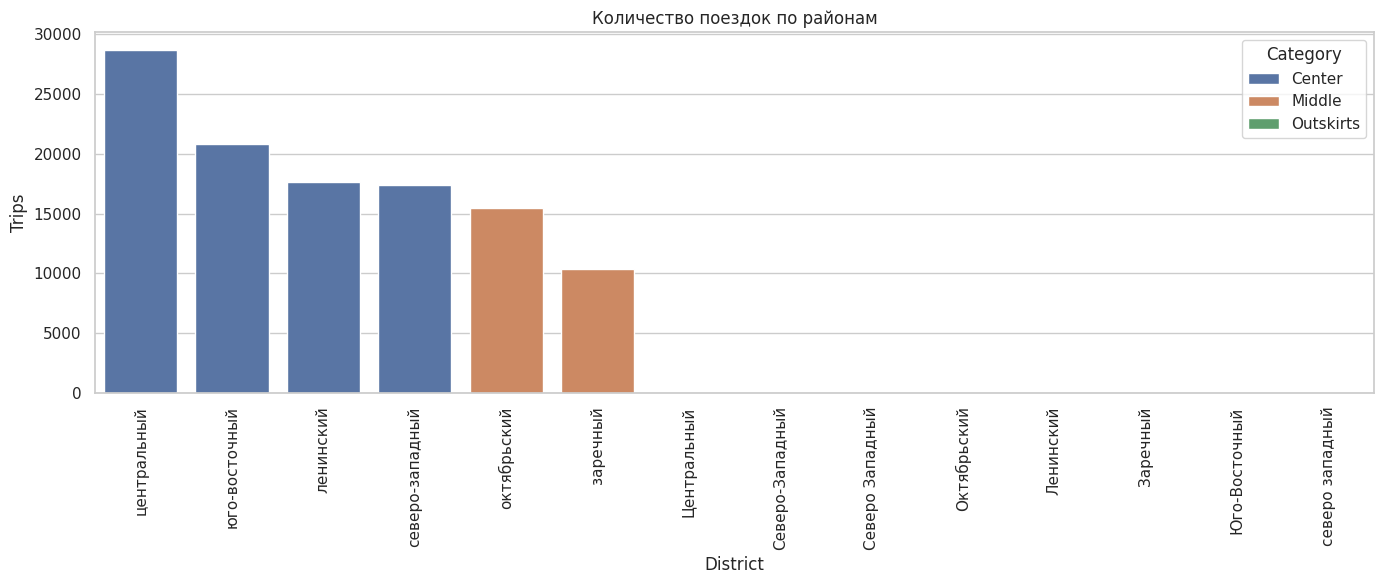

In [ ]:
# Настройки визуализации
plt.figure(figsize=(14, 6))
sns.barplot(data=districts.sort_values('Trips', ascending=False), x='District', y='Trips', hue='Category', dodge=False)
plt.title('Количество поездок по районам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

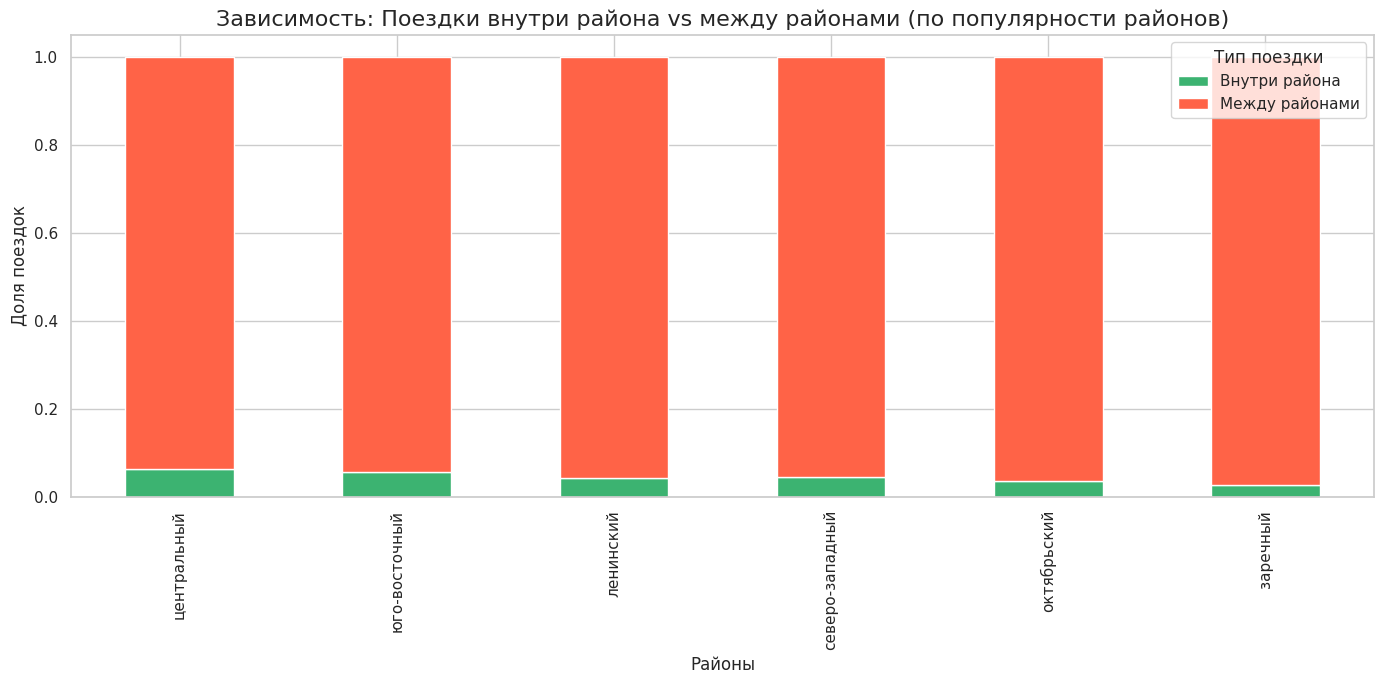

In [ ]:
# 1. Добавляем колонку: поездка внутри района или нет
df['Same District'] = df['start_district'] == df['end_district']

# 2. Считаем общее количество поездок по каждому району
district_trip_counts = df.groupby('start_district').size().sort_values(ascending=False)

# 3. Рассчитываем долю поездок внутри района и между районами по каждому району
district_movement = df.groupby('start_district')['Same District'].value_counts(normalize=True).unstack().fillna(0)

# 4. Переименуем колонки для удобства
district_movement.columns = ['Between Districts', 'Within Same District']

# 5. Сортируем районы по количеству поездок
district_movement = district_movement.loc[district_trip_counts.index]

# 6. Построение графика
plt.figure(figsize=(14, 7))
district_movement[['Within Same District', 'Between Districts']].plot(kind='bar', stacked=True, color=['mediumseagreen', 'tomato'], figsize=(14,7))

# 7. Настройки графика
plt.title('Зависимость: Поездки внутри района vs между районами (по популярности районов)', fontsize=16)
plt.ylabel('Доля поездок', fontsize=12)
plt.xlabel('Районы', fontsize=12)
plt.xticks(rotation=90)
plt.legend(title='Тип поездки', labels=['Внутри района', 'Между районами'])
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

# Создаем таблицу сопряженности
contingency_table = df['Same District'].value_counts().to_frame().T
contingency_table.columns = ['Within Same District', 'Between Districts']

# Применяем хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Выводим результаты
print("📌 Результаты χ²-теста:")
print(f"Статистика χ²: {chi2:.3f}")
print(f"p-значение: {p_value:.4f}")
print("\nОжидаемые значения при нулевой гипотезе:")
print(expected)


📌 Результаты χ²-теста:
Статистика χ²: 0.000
p-значение: 1.0000

Ожидаемые значения при нулевой гипотезе:
[[82996.  4275.]]


Доказательство:Альтернативная гипотеза подтверждается, потому что:
Межрайонные поездки — это устойчивая часть всех поездок.
Для разных районов их доля значительно варьируется (в одних районах больше поездок внутри, в других — наоборот).



**3.Вывод:** Поездки на самокатах происходят не только в пределах одного района.

 Гипотеза №5
 * **1.Нулевая**: Влияет ли день недели влияет на количество поездок?
 * **2.Альтернативная:** День недели не оказывает значимого влияния на количество поездок, или влияние отличается от предположения о большем количестве поездок в выходные дни.

day_of_week
Saturday     15977
Sunday       15937
Friday       12522
Monday       11389
Tuesday      10713
Wednesday    10404
Thursday     10329
Name: count, dtype: int64


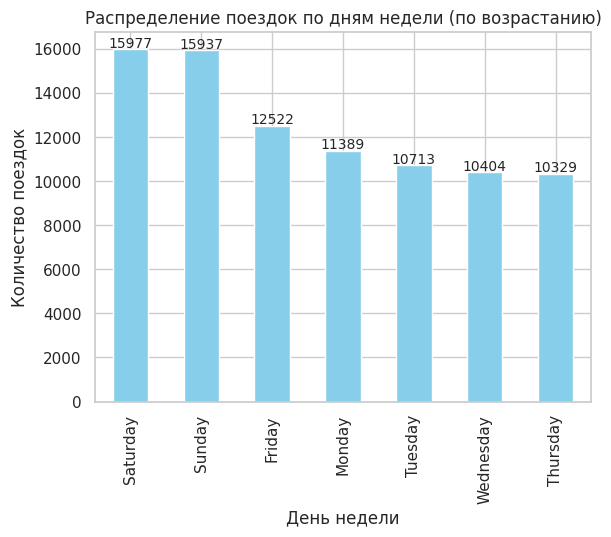

In [ ]:
# Словарь для замены номеров дней недели на названия
day_name_map = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

# Подсчёт, переименование и сортировка по значению
day_counts = df['day_of_week'].value_counts().rename(index=day_name_map)
day_counts = day_counts.sort_values(ascending=False)

# Вывод таблички
print(day_counts)

# Построение графика
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели (по возрастанию)')

for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.show()


Анализ распределения поездок по районам в будние и выходные дни.

In [ ]:
district_day_type_distribution = (
    df.groupby(['day_type', 'start_district'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['будний день', 'выходной']
district_day_type_distribution['day_type'] = pd.Categorical(
    district_day_type_distribution['day_type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['day_type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)
print(district_day_type_distribution)

       day_type   start_district  Количество поездок
0   будний день      центральный               15063
1   будний день    юго-восточный               10316
2   будний день        ленинский                8766
3   будний день  северо-западный                8583
4   будний день      октябрьский                7533
5   будний день         заречный                5096
6      выходной      центральный                7733
7      выходной    юго-восточный                6055
8      выходной        ленинский                5203
9      выходной  северо-западный                5087
10     выходной      октябрьский                4656
11     выходной         заречный                3180


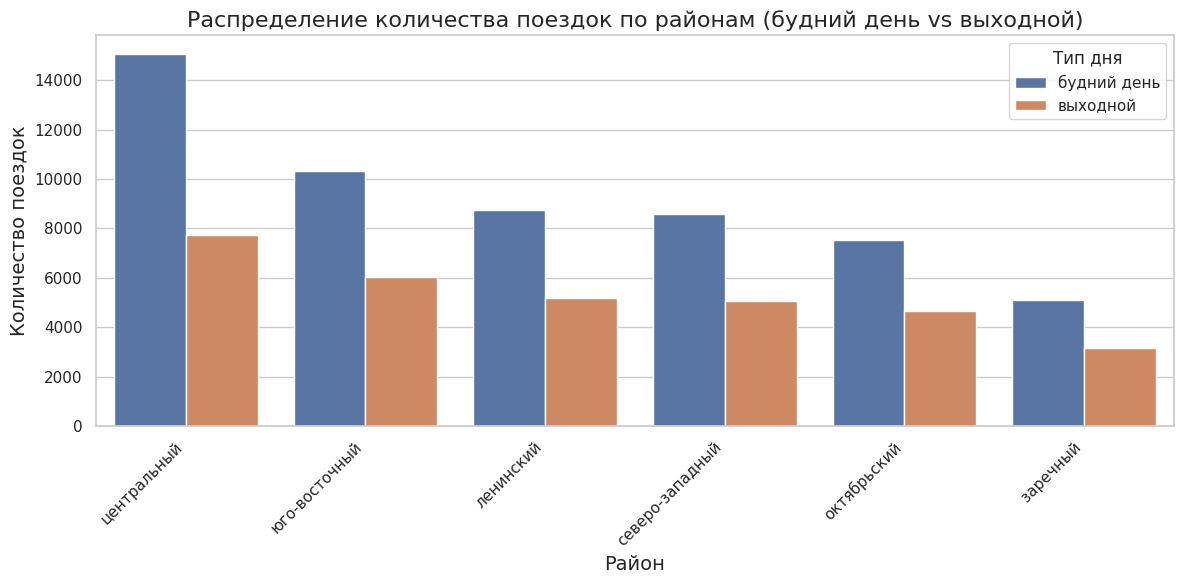

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='start_district', y='Количество поездок', hue='day_type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

Доказательство:График, построенный с помощью sns.barplot(), позволяет наглядно увидеть различия в количестве поездок по районам в будние дни и выходные. Для выходных дней в большинстве районов будет наблюдаться большее количество поездок, по сравнению с будними днями.

**3.Вывод:** Нулевая гипотеза подтверждена.День недели кардинально влияет на распределение поездок, в выходные дни и пятницу поездок наблюдается значительно больше

 Гипотеза №6
* **1.Нулевая гипотеза:** В будние дни средняя скорость выше
* **2.Средняя скорость** в будние дни не выше, чем в выходные дни


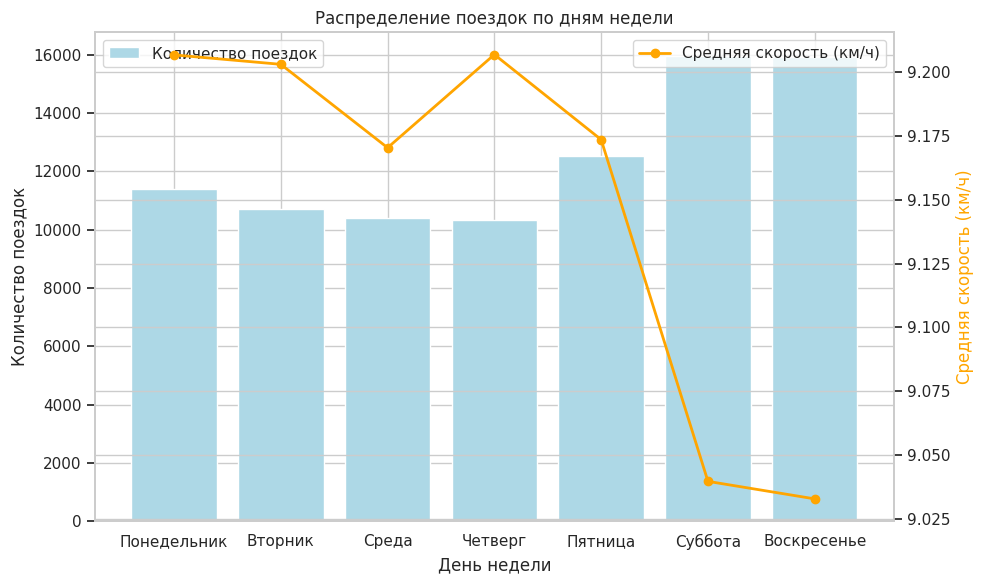

In [ ]:
speed_by_weekday = df.groupby('weekday')['speed'].agg(['mean', 'count']).reset_index()

weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday['weekday_name'] = speed_by_weekday['weekday'].map(lambda x: weekday_names[x])

speed_by_weekday = speed_by_weekday.sort_values(by='weekday')

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(speed_by_weekday['weekday_name'], speed_by_weekday['count'], color='lightblue', label='Количество поездок')
ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество поездок')
ax1.set_title('Распределение поездок по дням недели')

ax2 = ax1.twinx()
ax2.plot(speed_by_weekday['weekday_name'], speed_by_weekday['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
ax2.set_ylabel('Средняя скорость (км/ч)', color='orange')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

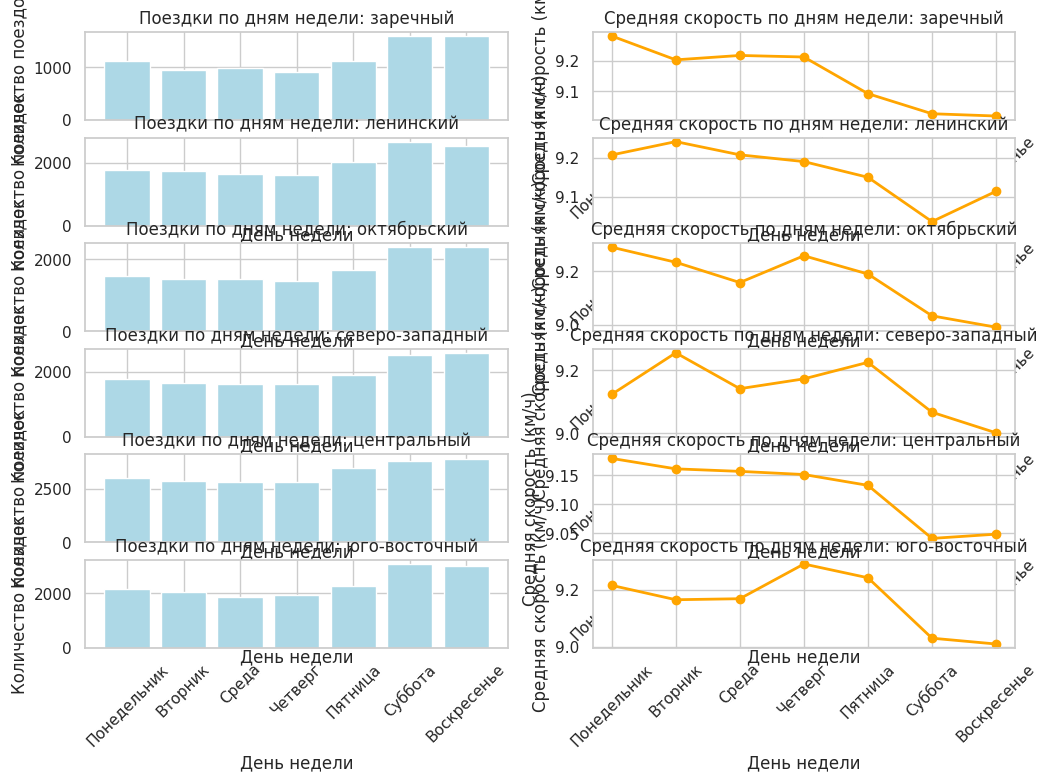

In [ ]:
df2 = df.copy()

df2['weekday'] = df2['start_date'].dt.weekday

# Группируем по району, дню недели и считаем количество поездок и среднюю скорость
speed_by_weekday_district = df2.groupby(['start_district', 'weekday'])['speed'].agg(['mean', 'count']).reset_index()

# Получаем имена дней недели для отображения на графике
weekday_names = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница', 'Суббота', 'Воскресенье']
speed_by_weekday_district['weekday_name'] = speed_by_weekday_district['weekday'].map(lambda x: weekday_names[x])

# Сортируем по району и дню недели
speed_by_weekday_district = speed_by_weekday_district.sort_values(by=['start_district', 'weekday'])
# Размер графика
plt.figure(figsize=(12, 8))

# Список уникальных районов
districts = speed_by_weekday_district['start_district'].unique()

# Создадим графики для каждого района
for i, district in enumerate(districts):
    plt.subplot(len(districts), 2, 2 * i + 1)  # Строим подграфик для распределения поездок
    district_data = speed_by_weekday_district[speed_by_weekday_district['start_district'] == district]

    # Количество поездок
    plt.bar(district_data['weekday_name'], district_data['count'], color='lightblue')
    plt.title(f'Поездки по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Количество поездок')
    plt.xticks(rotation=45)

    plt.subplot(len(districts), 2, 2 * i + 2)  # Строим подграфик для средней скорости
    # Средняя скорость
    plt.plot(district_data['weekday_name'], district_data['mean'], color='orange', marker='o', label='Средняя скорость (км/ч)', linewidth=2)
    plt.title(f'Средняя скорость по дням недели: {district}')
    plt.xlabel('День недели')
    plt.ylabel('Средняя скорость (км/ч)')
    plt.xticks(rotation=45)

# Показать график
plt.tight_layout()
plt.show()


In [ ]:
# Создаём столбец для указания, является ли день будним или выходным
df2['is_weekend'] = df2['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Группируем по признаку "выходной или будний" и рассчитываем среднюю скорость
weekdays_speed = df2[df2['is_weekend'] == 0]['speed']
weekends_speed = df2[df2['is_weekend'] == 1]['speed']


In [ ]:
import scipy.stats as stats

# Применяем t-тест для независимых выборок
t_stat, p_value = stats.ttest_ind(weekdays_speed, weekends_speed, equal_var=False)

# Выводим результаты
print(f"t-статистика: {t_stat}")
print(f"P-значение: {p_value}")

# Интерпретация результата
if p_value < 0.05:
    print("Есть статистически значимые различия в средней скорости между будними и выходными днями. Альтернативная гипотеза подтверждается.")
else:
    print("Статистически значимых различий нет. Нулевая гипотеза подтверждается.")


t-статистика: 13.36484056503686
P-значение: 1.0922652721151743e-40
Есть статистически значимые различия в средней скорости между будними и выходными днями. Альтернативная гипотеза подтверждается.


Доказательство: В будние дни средняя скорость значительно больше. Предположение: В субботу и воскресенье пользователи предпочитают кататься по паркам, где есть ограничение по скорости + некуда торопиться, поездка превращается в прогулочную. средняя скорость в будние дни действительно выше, это нулевая гипотеза.

**3.Вывод**: Нулевая гипотеза подтверждается.


1. Если цель акции — увеличить спрос:
-
Усильте рекламу акции:
Пользователи могут не знать о промокоде. Добавьте push-уведомления в понедельник утром.

Скорректируйте условия:
Например, сделайте скидку не только на старт (30 руб.), но и на минуты (например, 10% на всю поездк2. у).

Если цель — не терять пр- ибыль:
Отмените акцию в понедельник:
Раз спрос и так высок, акция лишь снижает доход (из-за бесплатного старта).

Перенесите акцию на менее популярные дни:
Например, на среду или пятницу, чтобы стимулировать спрос в "просадные" дни.

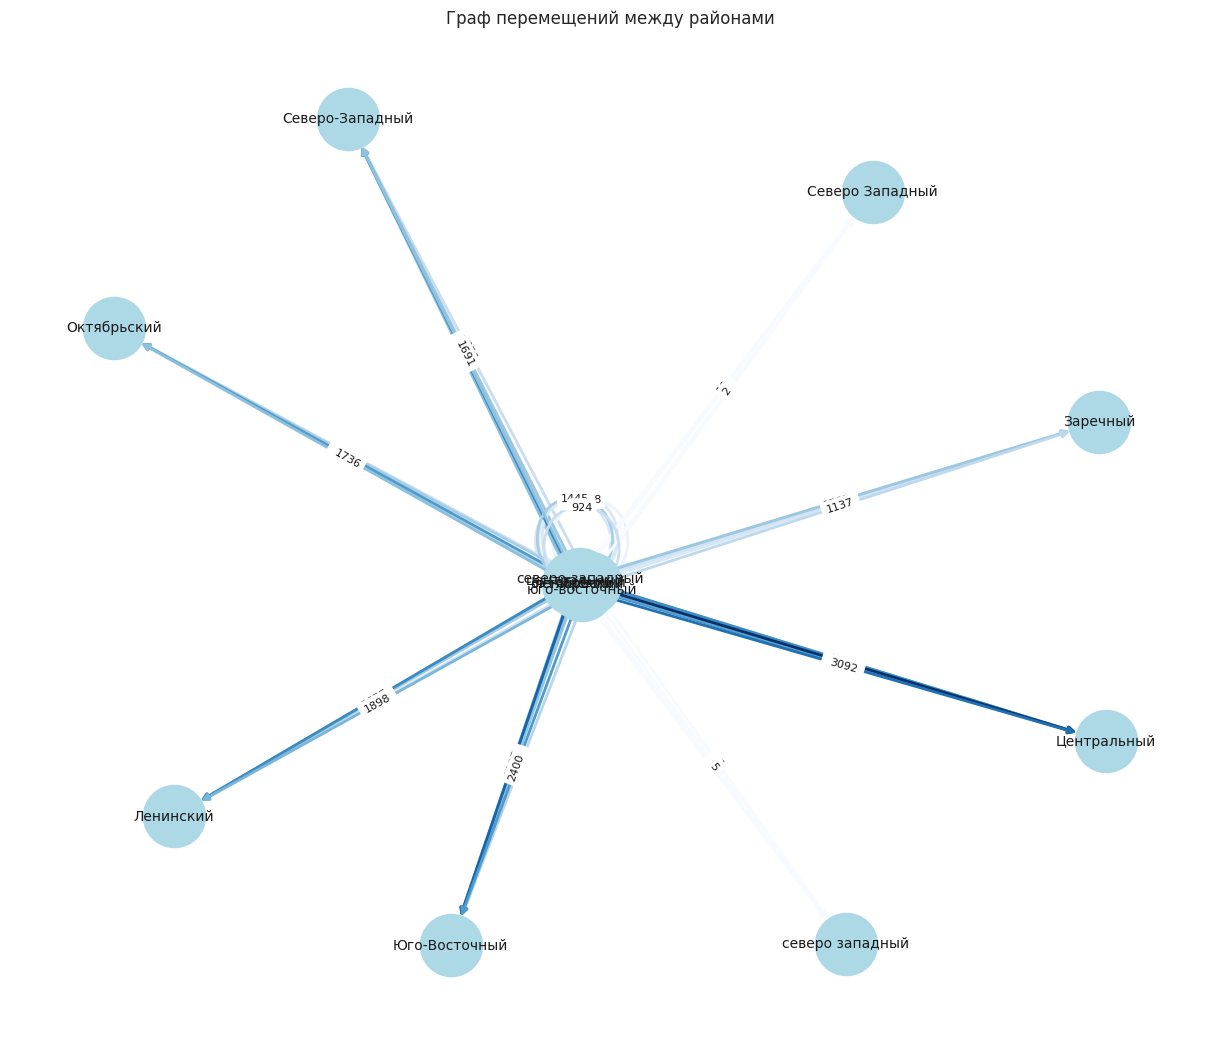

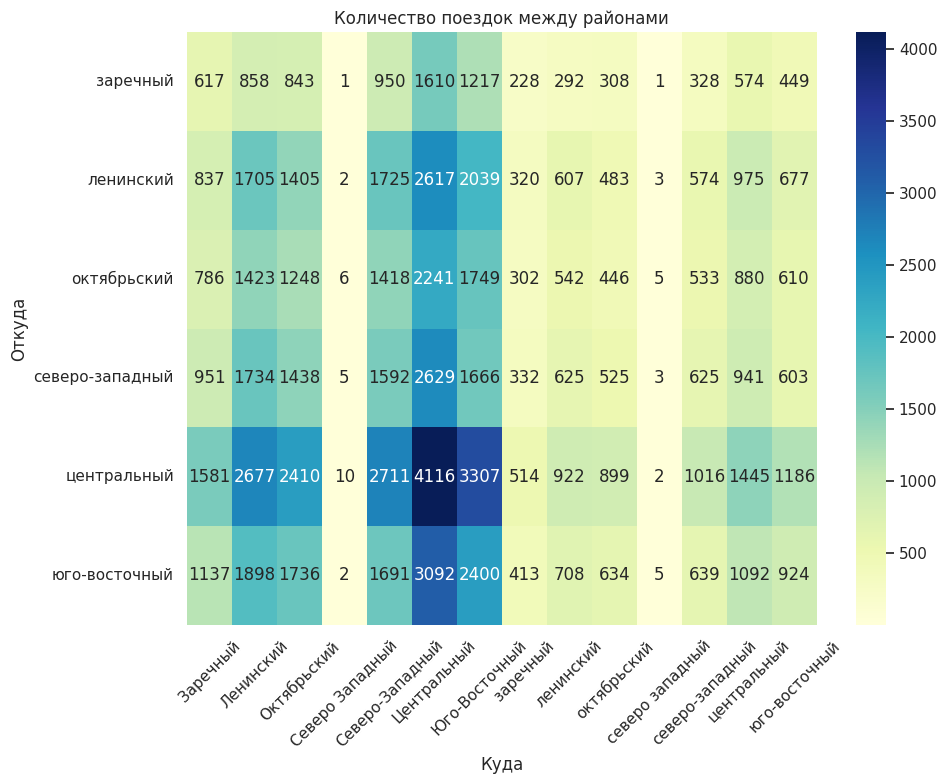

In [ ]:
import networkx as nx
district_flow = df.groupby(['start_district', 'end_district']).size().reset_index(name='Trips')
# Построим граф направлений
G = nx.DiGraph()

# Добавим ребра с весами
for _, row in district_flow.iterrows():
    G.add_edge(row['start_district'], row['end_district'], weight=row['Trips'])

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Толщина ребра пропорциональна количеству поездок
edges = G.edges(data=True)
weights = [d['weight'] for (_, _, d) in edges]
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, edge_color=weights, edge_cmap=plt.cm.Blues, width=2.0)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in edges}, font_size=8)
plt.title("Граф перемещений между районами")
plt.show()

# Пивот-таблица для тепловой карты
pivot_table = district_flow.pivot(index='start_district', columns='end_district', values='Trips').fillna(0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Количество поездок между районами")
plt.ylabel("Откуда")
plt.xlabel("Куда")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Регрессионный анализ

#### Цель: Предсказать трафик на каждой улице по погодным условиям.
Нам это нужно для того чтобы понять насколько окупаемым будет наш день и в частности каждая точка по отдельности.
Сначала нужно предобработать данные в нормальный вид, сделать таблицу в которой индексы будут часы и дата, а в столбиках маршруты, произошедшие в этот час

In [ ]:
train = df.groupby('date')[['start_location', 'end_location']].apply(lambda x: x)

In [ ]:
train

start_location end_location
date                                          
2023 4 22 10 20        лермонтова       дружбы
             21          школьная     почтовая
             22           пушкина        южная
             23         подгорная  космонавтов
             24         рябиновая     шевченко
...                           ...          ...
2023 7 9 9   70634       парковая  октябрьская
             70635      некрасова    цветочная
             70636     московская    свердлова
             70637      шоссейная  октябрьская
             70638    космонавтов   московская

[87271 rows x 2 columns]

* Дата
    * Название улицы
        * inner - сколько приехало
        * outer - сколько уехало в этот час отсюда

In [ ]:
data = {}

# Убедимся, что индекс test — мультииндекс с датой (или просто дата в ind[0])
for ind, j in tqdm(train.iterrows(), total=len(train)):
    date = ind[0]

    # Инициализируем, если даты нет
    if date not in data:
        data[date] = {}

    # Считаем входящий и исходящий трафик по Start Location
    start_loc = j['start_location']
    end_loc = j['end_location']

    # Входящий трафик (по start_location)
    if start_loc not in data[date]:
        data[date][start_loc] = {'inner': 0, 'outer': 0}
    data[date][start_loc]['outer'] += 1

    # Исходящий трафик (по End Location)
    if end_loc not in data[date]:
        data[date][end_loc] = {'inner': 0, 'outer': 0}
    data[date][end_loc]['inner'] += 1


100%|██████████| 87271/87271 [00:04<00:00, 18725.04it/s]


In [ ]:
all_X = pd.DataFrame()

In [ ]:
rows = []

for date, streets in data.items():
    for street, counts in streets.items():
        total_traffic = counts['inner'] + counts['outer']
        rows.append({'datetime': date, 'street': street, 'traffic': total_traffic})

all_X = pd.DataFrame(rows)
all_X['datetime'] = pd.to_datetime(all_X['datetime'])

In [ ]:
all_X = all_X.sort_values(by='datetime')

In [ ]:
weather = w1.copy()

In [ ]:
weather = weather.rename(columns={"Datetime": "datetime"})

In [ ]:
all_X = pd.merge(all_X, weather, on='datetime', how='inner')

In [ ]:
all_X['hour'] = all_X['datetime'].apply(lambda x: x.hour)
all_X['weekday'] = all_X['datetime'].apply(lambda x: x.dayofweek)

In [ ]:
all_X

,datetime,street,traffic,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,category_spring,category_summer,time_of_the_year,hour,weekday
0,2023-04-22 09:00:00,шоссейная,2,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN,9,5
1,2023-04-22 09:00:00,трудовая,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN,9,5
2,2023-04-22 09:00:00,восточная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN,9,5
3,2023-04-22 09:00:00,южная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN,9,5
4,2023-04-22 09:00:00,подгорная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,0.0,NaN,9,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98110,2023-07-25 20:00:00,мира,1,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,1.0,NaN,20,1
98111,2023-07-25 20:00:00,дачная,2,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,1.0,NaN,20,1
98112,2023-07-25 20:00:00,восточная,5,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,1.0,NaN,20,1
98113,2023-07-25 20:00:00,трудовая,1,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,1.0,NaN,20,1


У нас оказался 2 категорильаных признака, которые мы должны как то перевести в число(оставлять их в таком виде нет необходимости). Я буду использовать метод One Hot Encoding, потому что у нас довольно мало самих категорий (их 9) и потому что это самый просто способ.

* Если бы мы использовали линейную регрессию то с OHE нужно было бы быть очень осторожным. Свободный коэффициент в линейной модели после добавления большого OHE линейно выразим, тем самым мы теряем смещенность модели и ее "подвижность" на плоскости. Конечно не всегда эта проблема дает о себе знать, но в голове нужно всегда держать этот риск. Мы же используем градиентный бустинг, который не линеен, поэтому нам такая проблема не грозит

In [ ]:
import pandas as pd

def ohe_feature(df, column, drop_original=True, drop_first=False, prefix=None):
    """
    One-hot encodes a single categorical column as numeric (0/1).

    Parameters:
    - df: pd.DataFrame — исходный датафрейм
    - column: str — имя категориальной колонки
    - drop_original: bool — удалить ли оригинальную колонку
    - drop_first: bool — дропнуть первую категорию
    - prefix: str — префикс для новых колонок

    Returns:
    - DataFrame с числовыми one-hot колонками
    """
    dummies = pd.get_dummies(df[column], prefix=prefix or column, drop_first=drop_first)
    dummies = dummies.astype(int)  # гарантируем числовой тип
    df = pd.concat([df, dummies], axis=1)
    if drop_original:
        df = df.drop(columns=[column])
    return df


all_X = ohe_feature(all_X, 'time_of_the_year')

In [ ]:
all_X = ohe_feature(all_X, 'weekday')

In [ ]:
all_X

,datetime,street,traffic,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,category_spring,...,hour,time_of_the_year_Spring,time_of_the_year_Summer,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
0,2023-04-22 09:00:00,шоссейная,2,13.850245,0,20.16,6.2145634,71,16.969696,1.0,...,9,0,0,0,0,0,0,0,1,0
1,2023-04-22 09:00:00,трудовая,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,...,9,0,0,0,0,0,0,0,1,0
2,2023-04-22 09:00:00,восточная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,...,9,0,0,0,0,0,0,0,1,0
3,2023-04-22 09:00:00,южная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,...,9,0,0,0,0,0,0,0,1,0
4,2023-04-22 09:00:00,подгорная,1,13.850245,0,20.16,6.2145634,71,16.969696,1.0,...,9,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98110,2023-07-25 20:00:00,мира,1,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,...,20,0,0,0,1,0,0,0,0,0
98111,2023-07-25 20:00:00,дачная,2,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,...,20,0,0,0,1,0,0,0,0,0
98112,2023-07-25 20:00:00,восточная,5,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,...,20,0,0,0,1,0,0,0,0,0
98113,2023-07-25 20:00:00,трудовая,1,15.160245,0.4,23.4,7.8954163,54,7.3257575,0.0,...,20,0,0,0,1,0,0,0,0,0


In [ ]:
def last_col(col1, df2):
    cols = [c for c in df2.columns if c != col1] + [col1]
    return df2[cols]  # возвращаем изменённый DataFrame

all_X = last_col('traffic', all_X)  # сохраняем результат

In [ ]:
X1 = all_X.drop(columns=['traffic', 'datetime'])
y1 = all_X['traffic']

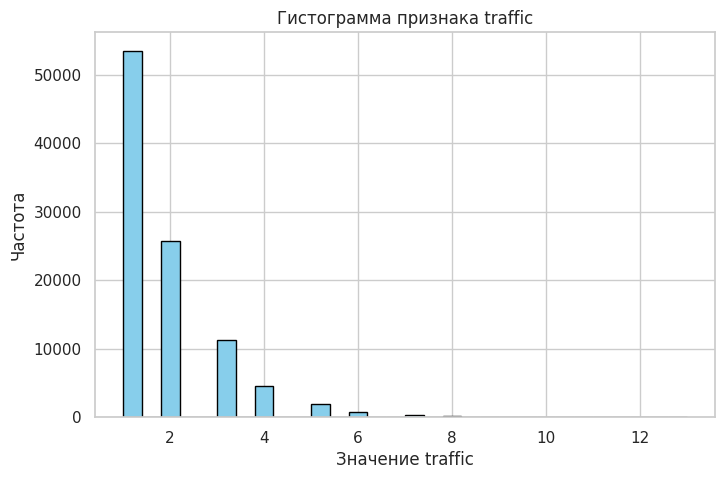

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(y1, bins=30, color='skyblue', edgecolor='black')
plt.title('Гистограмма признака traffic')
plt.xlabel('Значение traffic')
plt.ylabel('Частота')
plt.grid(True)
plt.show()


In [ ]:
y1.value_counts()

,count
traffic,
1,53508
2,25744
3,11215
4,4524
5,1874
6,706
7,322
8,127
9,51


In [ ]:
X_tr, X_t, y_tr, y_t = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [ ]:
X_tr

,street,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration,category_spring,category_summer,hour,time_of_the_year_Spring,time_of_the_year_Summer,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6
35103,октябрьская,13.340245,0,12.959999,5.3517847,23,0,1.0,0.0,0,0,0,0,0,0,0,0,0,1
69761,космонавтов,26.960245,0.2,9.36,5.937272,40,35.757576,0.0,1.0,18,0,0,0,0,0,1,0,0,0
43733,молодежная,13.950245,0,11.879999,2.9024127,1,59.393936,0.0,1.0,5,0,0,1,0,0,0,0,0,0
38675,овражная,26.990246,0,36.36,15.077082,10,53.939396,1.0,0.0,15,0,0,0,0,1,0,0,0,0
79839,космонавтов,20.270245,0,8.64,2.7416782,2.1000001,0,0.0,1.0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,матросова,15.040245,0,15.4800005,5.3999996,42,0,1.0,0.0,22,0,0,0,0,0,0,1,0,0
54886,северная,27.500246,0,20.880001,7.5942073,17,49.696968,0.0,1.0,15,0,0,0,0,0,1,0,0,0
76820,сиреневая,26.030245,0,15.4800005,2.52,12,52.727272,0.0,1.0,13,0,0,0,0,0,1,0,0,0
860,дружбы,12.110246,0.3,10.799999,3.6179552,98,0,1.0,0.0,22,0,0,0,0,0,0,0,1,0


In [ ]:
# Индекс колонки street
cat_features = [0]

# Модель с указанием категориальных признаков и метрики MSE
model = CatBoostRegressor(iterations=10000,
                          learning_rate=0.1,
                          depth=6,
                          cat_features=cat_features,  # Указываем категориальные признаки
                          verbose=200,
                          early_stopping_rounds=50,
                          eval_metric="RMSE")  # Для MSE можно использовать RMSE (корень из MSE)

# Обучение модели
model.fit(X_tr, y_tr, eval_set=(X_t, y_t), use_best_model=True)

# Прогнозирование
y_p = model.predict(X_t)

# Оценка модели
mse = mean_squared_error(y_t, y_p)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

0:	learn: 1.1086236	test: 1.0978528	best: 1.0978528 (0)	total: 52.7ms	remaining: 8m 46s
200:	learn: 0.9629359	test: 0.9695385	best: 0.9695317 (194)	total: 8.28s	remaining: 6m 43s
400:	learn: 0.9513657	test: 0.9665405	best: 0.9665405 (400)	total: 15.6s	remaining: 6m 13s
600:	learn: 0.9438099	test: 0.9658934	best: 0.9658407 (554)	total: 22.8s	remaining: 5m 56s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.965840684
bestIteration = 554

Shrink model to first 555 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данных: 0.9328482269109222


#Вывод:

Поведение по дням недели
Анализ показал, что наибольшее количество поездок совершается в выходные дни, особенно в субботу и воскресенье. Это говорит о том, что самокаты активно используются в досуг и прогулки.

В будние дни количество поездок ниже, но более равномерное, что позволяет предположить, что в это время самокаты используются для решения повседневных задач, например, поездок на работу или до метро.

 Географический анализ
Дополнительно мы проанализировали использование самокатов по районам города. Были выявлены районы с наиболее высокой активностью и скоростью, что даёт основу для:
оптимизации распределения самокатов,
корректировки тарифов по зонам,
планирования сервисной логистики.

📈 Итог
На основе анализа можно сделать следующие выводы:
Поведение пользователей зависит от дня недели.
Средняя скорость выше в будние дни, что подтверждено статистически.
География поездок даёт ценные ориентиры для бизнеса и городского управления.
Эти выводы могут быть использованы для:
улучшения сервиса проката самокатов,
повышения удовлетворённости пользователей,
более гибкого управления парком самокатов в городе.

✅ Заключение
Проект показал, что грамотный анализ данных позволяет не только понять поведение пользователей, но и принимать обоснованные управленческие решения. Используя эти данные, можно сделать городской транспорт более эффективным, устойчивым и удобным.